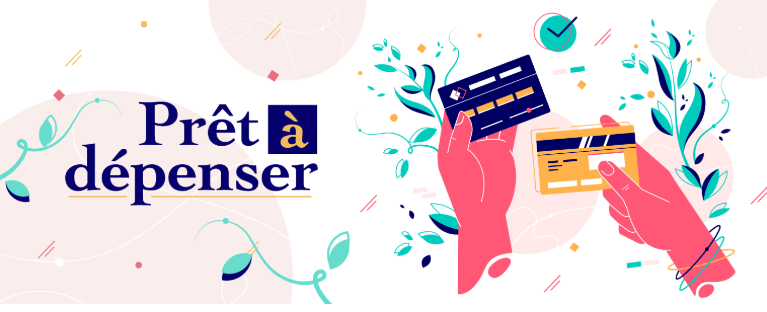

# Introduction - Import librairies & check versions

In [2]:
# %load_ext pycodestyle_magic
# %pycodestyle_on
# %pycodestyle_off

In [3]:
# utilities
import sys
import itertools
from datetime import datetime
from functions import *
import os
from joblib import dump
import warnings
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
from joblib import dump, load
from pprint import pprint

# data transformation
import numpy as np
import pandas as pd

# maths & stats
import random

# serialization
import pickle

# data pre-processing
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.model_selection import (train_test_split, RandomizedSearchCV, GridSearchCV, KFold, StratifiedKFold, RepeatedStratifiedKFold,
learning_curve, cross_val_score)
from sklearn.pipeline import Pipeline as Pipeline_sk
from imblearn.pipeline import Pipeline as Pipeline_imb
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
import imblearn
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# visualisation
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, StrMethodFormatter
import seaborn as sns
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# dummy model
from sklearn.dummy import DummyClassifier

# linear regression models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ensemble learning models
import lightgbm
from lightgbm import LGBMClassifier
import xgboost as xgb
from xgboost import XGBClassifier

# model selection & performance metrics
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, average_precision_score, recall_score, f1_score,
fbeta_score, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, make_scorer)
from timeit import default_timer as timer

# feature importance analysis
import shap
# shap.initjs()

# experiment tracking
import mlflow
import mlflow.pyfunc
from mlflow.models import infer_signature, convert_input_example_to_serving_input, validate_serving_input, model
from mlflow import MlflowClient
from mlflow.pyfunc import PythonModel

# configure transformers to output pandas DataFrames
from sklearn import set_config
set_config(transform_output="pandas")

# set dataframe display options
pd.set_option('max_colwidth', None)
pd.set_option('display.max_columns', None)

# remove scientific notation
pd.set_option('display.float_format', lambda x: '%.5f' % x)

# disable convergence warnings after checking
# simplefilter("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# initialise random state for all models and transformers
rs_list = [8, 13, 42]
rs = rs_list[random.randrange(len(rs_list))]
print("Random state =", rs)

Random state = 13


In [4]:
# define color palettes for graphs
viridis_palette = ['#440154', '#481e70', '#443982', '#3a528b', '#30678d', '#287b8e', '#20908c', '#20a485', '#35b778', '#5ec961',
                   '#90d643', '#c7e01f', '#fde724']

sunset_palette = ["#FFEB3B", "#FFDA44", "#FFC107", "#FFB300", "#FFA000", "#FF8F00", "#FF6F00", "#FF5722", "#FF3D00", "#FF2D00",
                  "#E53935", "#D32F2F", "#C62828", "#B71C1C", "#FF5252", "#FF1744", "#FF4081", "#F50057", "#D5006D", "#C51162"]

palette = ['#440154', '#481e70', '#443982', '#3a528b', '#30678d', '#287b8e', '#20908c', '#20a485', '#35b778', '#5ec961',
           '#90d643', '#c7e01f', '#fde724', "#FFEB3B", "#FFDA44", "#FFC107", "#FFB300", "#FFA000", "#FF8F00", "#FF6F00",
           "#FF5722", "#FF3D00", "#FF2D00", "#E53935", "#D32F2F", "#C62828", "#B71C1C", "#FF5252", "#FF1744", "#FF4081",
           "#F50057", "#D5006D", "#C51162"]

In [5]:
# check librairies versions
print("Librairies versions : \n")
print("numpy -", np.__version__)
print("pandas -", pd.__version__)
print("seaborn -", sns.__version__)
print("python -", sys.version[0:6])
print("imbalanced-learn:", imblearn.__version__)
print("lightGBM:", lightgbm.__version__)
print("XGBoost:", xgb.__version__)
print("SHAP: ", shap.__version__)

Librairies versions : 

numpy - 2.0.2
pandas - 2.2.3
seaborn - 0.13.2
python - 3.13.2
imbalanced-learn: 0.13.0
lightGBM: 4.5.0
XGBoost: 2.1.4
SHAP:  0.47.0


**Note : lightGBM was downgraded to version 4.5.0 due to the following error when invoking mlflow.lightgbm.autolog():**

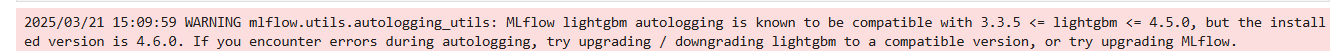

**Note : XGBoost was downgraded to version 2.1.4 due to the following error when invoking mlflow.xgboost.autolog():**

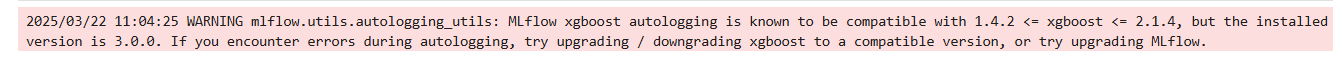

# 1 - Modelisation

## 1.1 - Set-up

### 1.1.1 - Import data

In [6]:
# Import data
X_train = pd.read_csv('X_train_final.csv')
X_test = pd.read_csv('X_test_final.csv')
X_val = pd.read_csv('X_val_final.csv')
y_train = pd.read_csv('y_train_final.csv')
y_test = pd.read_csv('y_test_final.csv')
y_val = pd.read_csv('y_val_final.csv')

In [7]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

(215257, 56)
(46127, 56)
(46127, 56)
(215257, 1)
(46127, 1)
(46127, 1)


In [8]:
X_val.head()

,NAME_CONTRACT_TYPE,INCOME_TYPE,EMPLOYMENT_SECTOR,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT_W_CITY,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,b_AMT_CREDIT_MAX_OVERDUE_max,b_AMT_CREDIT_SUM_OVERDUE_mean,pcb_CNT_INSTALMENT_FUTURE_max,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_CARD_OVERDRAWN_%_mean,ip_EARLY_PMT_mean,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,TOTAL_APPROVED_CREDITS,TOTAL_PAYMENT_DELAYS_DAYS,TOTAL_ACTIVE_CAR_LOANS,TOTAL_ACTIVE_OTHER_LOANS,TOTAL_ACTIVE_CONSUMER_LOANS,TOTAL_ACTIVE_MICRO_LOANS,TOTAL_ACTIVE_MORTGAGES,TOTAL_ACTIVE_CREDIT_CARDS,DEBT_RENEGOCIATIONS,CLIENT_BAD_CREDIT_HISTORY,CLIENT_FRAUD_FLAG,CLIENT_WITHDRAWN_APPLICATIONS,DOWN_PAYMENT_CURR_%,DEBT_RATE_INC_CURR_%,IS_MALE,WHITE_COLLAR,UPPER_EDUCATION,IS_MARRIED,LIVES_INDEPENDENTLY
0,Cash loans,fixed_salary,tertiary,0,0,269550.00000,-2835,-5092,0,3,0,0,-217,118584.00000,39528.00000,37,-0.06944,1,1,1,0.42933,0.05000,4,0.00000,0.00000,6,0.00000,0.00000,0.00000,11.22222,0.00000,0.00000,256536.00000,0.10447,0,8.81183,3,13,11.85716,0,5,6,0,1,1,0,3,5,3,-0.19800,67.14060,0,0,0,1,1
1,Cash loans,fixed_salary,tertiary,1,1,1546020.00000,-1538,-2715,0,2,7,0,-2327,114858.00000,38286.00000,31,-0.41795,1,1,1,0.54454,0.05000,1,14575.23922,0.00000,11,189000.00000,0.00000,0.00000,31.60000,0.00000,0.00000,38613.75000,0.04134,2,8.40239,2,13,5.96173,0,1,5,0,0,3,0,0,6,0,-0.14520,23.86597,0,0,0,1,1
2,Cash loans,fixed_salary,tertiary,0,1,364896.00000,-640,-2792,1,2,5,0,-1486,89050.50000,44525.25000,36,-0.26557,1,1,1,0.63405,0.05000,3,10129.50000,0.00000,9,13170.73171,3.02439,0.34072,3.19178,0.00000,0.06849,61234.50000,0.20619,0,11.23200,2,7,0.96168,0,1,1,1,0,1,3,0,3,0,-0.15840,63.24100,0,0,1,1,1
3,Cash loans,commission,secondary,0,0,508495.50000,-8392,-3665,0,2,0,0,-1229,77328.00000,38664.00000,55,-0.02661,1,1,1,0.59349,0.05000,0,0.00000,0.00000,48,0.00000,0.00000,0.00000,4.78947,0.00000,0.00000,80880.75000,0.09609,1,15.10404,1,7,6.36744,0,1,3,0,0,1,0,0,2,0,-0.11880,40.90688,0,0,0,1,1
4,Revolving loans,fixed_salary,tertiary,0,0,202500.00000,-9082,-627,0,2,1,0,-779,57375.00000,28687.50000,46,-0.16276,1,1,1,0.59205,0.00000,1,0.00000,0.00000,24,0.00000,0.00000,0.00000,12.30769,0.00000,0.00000,118271.25000,0.10891,0,16.05271,1,8,-0.12065,0,0,3,0,0,2,0,0,2,0,0.00000,41.79035,0,1,0,1,1


In [9]:
X_train[['NAME_CONTRACT_TYPE', 'INCOME_TYPE', 'EMPLOYMENT_SECTOR']] = X_train[['NAME_CONTRACT_TYPE', 'INCOME_TYPE', 'EMPLOYMENT_SECTOR']].astype('str')
X_test[['NAME_CONTRACT_TYPE', 'INCOME_TYPE', 'EMPLOYMENT_SECTOR']] = X_test[['NAME_CONTRACT_TYPE', 'INCOME_TYPE', 'EMPLOYMENT_SECTOR']].astype('str')
X_val[['NAME_CONTRACT_TYPE', 'INCOME_TYPE', 'EMPLOYMENT_SECTOR']] = X_val[['NAME_CONTRACT_TYPE', 'INCOME_TYPE', 'EMPLOYMENT_SECTOR']].astype('str')

**Note : MLFlow is unable to convert category types to string type, triggers error "MlflowException: Incompatible input types for column <cat column>. Can not safely convert category to <U0." and also "MlflowException: Failed to enforce schema of data" as a result => make sure to convert these bacl to type 'str' when running loaded models from registry.**

In [10]:
X_train_val = pd.concat([X_train, X_val], axis=0, ignore_index=True, copy=True)
print(X_train_val.shape)

(261384, 56)


In [11]:
X_train_val.to_csv('X_train_val.csv', index=False)

In [12]:
y_train_val = pd.concat([y_train, y_val], axis=0, ignore_index=True, copy=True)
print(y_train_val.shape)

(261384, 1)


In [13]:
y_train_val.to_csv('y_train_val.csv', index=False)

### 1.1.2 - Define transformations pipelines for models

**Example from https://imbalanced-learn.org/stable/references/generated/imblearn.pipeline.make_pipeline.html#imblearn.pipeline.make_pipeline**

In [14]:
# split numerical and categorical columns and list column names
num_X = ['AMT_CREDIT', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH','REGION_RATING_CLIENT_W_CITY', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
         'DAYS_LAST_PHONE_CHANGE', 'DISPOSABLE_INCOME', 'DISPOSABLE_INCOME_per_capita', 'YEAR_BIRTH', 'REQUESTS_ABOUT_CLIENT_1Y',
         'b_AMT_CREDIT_MAX_OVERDUE_max', 'b_AMT_CREDIT_SUM_OVERDUE_mean', 'pcb_CNT_INSTALMENT_FUTURE_max',
         'ccb_AMT_CREDIT_LIMIT_ACTUAL_mean', 'ccb_CNT_DRAWINGS_TOTAL_mean', 'ip_EARLY_PMT_mean',  'pa_AMT_APPLICATION_mean',
         'pa_RATE_DOWN_PAYMENT_mean', 'pa_NFLAG_INSURED_ON_APPROVAL_sum', 'pa_REMAINING_CREDIT_DURATION_Y_mean', 'pa_CREDIT_SECURITY_sum',
         'TOTAL_APPROVED_CREDITS', 'TOTAL_PAYMENT_DELAYS_DAYS', 'TOTAL_ACTIVE_CAR_LOANS', 'TOTAL_ACTIVE_OTHER_LOANS',
         'TOTAL_ACTIVE_CONSUMER_LOANS', 'TOTAL_ACTIVE_MICRO_LOANS', 'TOTAL_ACTIVE_MORTGAGES', 'TOTAL_ACTIVE_CREDIT_CARDS', 'DEBT_RENEGOCIATIONS',
         'CLIENT_BAD_CREDIT_HISTORY', 'CLIENT_FRAUD_FLAG', 'CLIENT_WITHDRAWN_APPLICATIONS', 'DEBT_RATE_INC_CURR_%']

cat_X = ['NAME_CONTRACT_TYPE', 'INCOME_TYPE', 'EMPLOYMENT_SECTOR']

# check
print(len(num_X))

35


In [15]:
# preprocessing steps by data type - data fed into linear model w/ intercept !colinearity => drop a column
preproc_lin = ColumnTransformer(transformers=[('num', PowerTransformer(method='yeo-johnson', standardize=True, copy=True), num_X), 
                                              ('cat', OneHotEncoder(drop='first'), cat_X)],
                                              remainder='passthrough')

preproc_ens = ColumnTransformer(transformers=[('num', PowerTransformer(method='yeo-johnson', standardize=True, copy=True), num_X), 
                                              ('cat',OneHotEncoder(drop=None), cat_X)],
                                               remainder='passthrough')

-**Create preprocessed X_test for calculation of SHAP values in Streamlit app (Streamlit SHAP cannot handle pipelines)**

In [16]:
set_config(transform_output="default")
# preprocess X_test for calculation of SHAP values in Streamlit app (Streamlit SHAP cannot handle pipelines)
X_test_preprocessed = preproc_ens.fit_transform(X_test)
X_test_preprocessed_columns = preproc_ens.get_feature_names_out()
X_test_preprocessed = pd.DataFrame(X_test_preprocessed, columns=X_test_preprocessed_columns)
print(X_test_preprocessed.shape)
X_test_preprocessed.head()
X_test_preprocessed.to_csv('X_test_preprocessed.csv', index=False)

(46127, 63)


In [17]:
test_data = pd.read_csv('test_data_final.csv')
test_data = test_data.drop(labels=['Unnamed: 0'], axis=1)
print(test_data.shape)
test_data.head()

(48744, 56)


,NAME_CONTRACT_TYPE,INCOME_TYPE,EMPLOYMENT_SECTOR,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT_W_CITY,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,b_AMT_CREDIT_MAX_OVERDUE_max,b_AMT_CREDIT_SUM_OVERDUE_mean,pcb_CNT_INSTALMENT_FUTURE_max,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_CARD_OVERDRAWN_%_mean,ip_EARLY_PMT_mean,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,TOTAL_APPROVED_CREDITS,TOTAL_PAYMENT_DELAYS_DAYS,TOTAL_ACTIVE_CAR_LOANS,TOTAL_ACTIVE_OTHER_LOANS,TOTAL_ACTIVE_CONSUMER_LOANS,TOTAL_ACTIVE_MICRO_LOANS,TOTAL_ACTIVE_MORTGAGES,TOTAL_ACTIVE_CREDIT_CARDS,DEBT_RENEGOCIATIONS,CLIENT_BAD_CREDIT_HISTORY,CLIENT_FRAUD_FLAG,CLIENT_WITHDRAWN_APPLICATIONS,DOWN_PAYMENT_CURR_%,DEBT_RATE_INC_CURR_%,IS_MALE,WHITE_COLLAR,UPPER_EDUCATION,IS_MARRIED,LIVES_INDEPENDENTLY
0,Cash loans,fixed_salary,tertiary,0,1,568800.00000,-5170,-812,1,2,0,0,-1740,114439.50000,57219.75000,52,-0.20119,1,1,1,0.56726,0.05000,0,4695.10125,0.00000,4,0.00000,0.00000,0.00000,8.85714,0.00000,0.00000,24835.50000,0.10433,0,6.02050,1,10,10.12447,0,0,4,0,0,1,0,0,1,0,-0.26400,9.93027,0,0,1,1,1
1,Cash loans,fixed_salary,other,0,1,222768.00000,-9118,-1623,0,2,0,0,0,81630.00000,40815.00000,49,-0.42975,1,1,1,0.42987,0.05000,3,0.00000,0.00000,12,0.00000,0.00000,0.00000,23.66667,0.00000,0.00000,22308.75000,0.10896,0,8.34237,1,5,5.91918,0,1,3,0,0,1,0,0,2,1,-0.23760,15.48428,1,0,0,1,1
2,Cash loans,fixed_salary,tertiary,1,1,663264.00000,-2175,-3503,0,2,0,0,-856,132723.00000,66361.50000,54,-0.36030,1,1,1,0.57282,0.05000,5,19305.00000,0.00000,36,131718.75000,0.23958,0.02593,5.72258,0.00000,0.06452,130871.25000,0.06722,1,11.52331,1,10,0.89815,0,2,2,0,0,1,1,0,4,1,-0.05280,137.02686,1,0,1,1,1
3,Cash loans,fixed_salary,tertiary,0,1,1575000.00000,-2000,-4208,0,2,0,0,-1805,265981.50000,66495.37500,38,-0.29567,1,1,1,0.54937,0.05000,3,0.00000,0.00000,24,225000.00000,2.38776,0.00000,3.26549,0.00000,0.08850,49207.50000,0.05771,0,16.73333,3,18,0.00000,0,2,4,0,0,5,1,0,4,2,0.00000,23.17505,0,0,0,1,1
4,Cash loans,fixed_salary,tertiary,1,0,625500.00000,-4000,-4262,0,2,0,0,-821,147933.00000,49311.00000,35,-0.40763,1,1,1,0.48170,0.05000,2,6960.70693,147.64334,12,0.00000,0.00000,0.00000,12.25000,0.00000,0.00000,267727.50000,0.08755,0,14.56405,0,6,4.48469,0,1,1,0,0,1,0,0,2,1,0.00000,29.76720,1,0,0,1,1


In [18]:
# preprocess X_test for calculation of SHAP values in Streamlit app (Streamlit SHAP cannot handle pipelines)
test_data_preprocessed = preproc_ens.fit_transform(test_data)
test_data_preprocessed_columns = preproc_ens.get_feature_names_out()
test_data_preprocessed = pd.DataFrame(test_data_preprocessed, columns=test_data_preprocessed_columns)
print(test_data_preprocessed.shape)
test_data_preprocessed.head()
test_data_preprocessed.to_csv('test_data_preprocessed.csv', index=False)

(48744, 63)


### 1.1.3 - Define business evaluation metric

**Source : https://machinelearningmastery.com/cost-sensitive-learning-for-imbalanced-classification/**  
**See also https://dl.acm.org/doi/10.5555/1642194.1642224**

In [19]:
def business_value(y_true, y_pred, threshold):
    """
    Business metric to maximise the bank's return by penalizing prediction errors (false negatives & false positives) according to their respective 
    actual cost & opportunity cost for the bank. The metric is built on the following assumptions:
    - True positives have a value of zero as the bank will choose not to do any business with these customers (no revenue and no loss risk);
    - True negatives have a value of 0.05 ; the bank will do business with them and earn on average a 5% margin on the loan amount over its lifetime;
    - False positives have an opporunity cost for the bank equal to the opposite of the value of true negatives i.e. -0.05, as the bank will decline to do business
    with what are actually good customers, forfeiting a potential risk-free revenue;
    - False negatives are estimated to have an actual cost 10 times higher than false positives (that is -0.5), i.e. after taking into account the opportunity cost on the interest not
    earned because of the client defaulting before loan maturity and the uncertainty of recovering the loan amount even after foreclosure on the secured assets, 
    the bank stands to lose around half of the loan value on any such customer.
    The threshold is the custom threshold that maximises the evaluation metric chosen for the classification model.
    """
    
    # List of predictions based on a probability threshold
    y_thresh = [1 if i >= threshold else 0 for i in y_pred]
    
    # Confusion Matrix
    conf_matrix = confusion_matrix(y_true, y_thresh)
    
    # Number of True Negatives
    tn = conf_matrix[0, 0]
    # Number of False Positives
    fp = conf_matrix[0, 1]
    # Number of False Negatives
    fn = conf_matrix[1, 0]
    # Number of True Positives
    tp = conf_matrix[1, 1]
    
    # Total gain
    gain = 0 * tp + 0.05 * tn - 0.05 * fp - 0.5 * fn
    
    # Maximum gain
    max_gain = 0.05 * (fp + tn) + 0 * (fn + tp)
    
    # Minimum gain
    min_gain = -0.05 * (fp + tn) - 0.5 * (fn + tp)
    
     # Scaled Gain
    if max_gain == min_gain:
        return 0.5
    else:
        scaled_gain = (gain - min_gain)/(max_gain - min_gain)
        return scaled_gain

In [20]:
# Define performance metrics
scorers = {'F1_score':  make_scorer(f1_score),
           'F2_score': make_scorer(fbeta_score, beta=2),
           'AUC': make_scorer(roc_auc_score),
           'accuracy': make_scorer(accuracy_score),
           'balanced_accuracy': make_scorer(balanced_accuracy_score),
           'precision': make_scorer(precision_score),
           'avg_precision': make_scorer(average_precision_score),
           'recall': make_scorer(recall_score),
           'business_score': make_scorer(business_value)
}

### 1.1.4 - Initialise MLFlow

**Run this in Command Prompt first:  py -m mlflow server --host 127.0.0.1 --port 8080**

In [22]:
# Set our tracking server uri for logging
mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")

In [23]:
client = MlflowClient(tracking_uri="http://127.0.0.1:8080")

##  1.2 - Benchmark - Logistic regression

### 1.2.1 - Threshold optimisation

**Source: https://machinelearningmastery.com/threshold-moving-for-imbalanced-classification/**

In [51]:
# over = SMOTE(sampling_strategy=0.1, k_neighbors=best_k_reglog, random_state=rs)
# under = RandomUnderSampler(sampling_strategy=0.5, random_state=rs)

# Define the pipeline with both preprocessing and a model
# pipe_2 = Pipeline_imb(steps=[('preprocessor', preproc_lin), ('model', best_reglog_classif)])
# pipe_2 = Pipeline_imb(steps=[('preprocessor', preproc_lin), ('oversampling', over), ('undersampling', under), ('model', best_reglog_classif)])

# Fit the pipeline to your data
# pipe_reglog_best.fit(X_train, y_train.values.ravel())

# Predict probabilities with the best model
y_val_pred_proba_reglog = pipe_reglog_best.predict_proba(X_val)[:,1]

# Define thresholds to evaluate
thresholds_reglog = np.arange(0, 1, 0.001)

# Evaluate each threshold using F2 score
scores_reglog = [fbeta_score(y_val, (y_val_pred_proba_reglog >= t).astype('int'), beta=2) for t in thresholds_reglog]

# Find the optimal threshold
optimal_threshold_reglog_idx = np.argmax(scores_reglog)
optimal_threshold_reglog = thresholds_reglog[optimal_threshold_reglog_idx]

print(f"Optimal Threshold: {optimal_threshold_reglog:.3f}, F2 Score: {np.max(scores_reglog):.5f}")

Optimal Threshold: 0.469, F2 Score: 0.40010


### 1.2.2 - Modelisation

In [17]:
# Provide an experiment description that will appear in the UI
experiment_description_1 = (
    "This is the client scoring project. "
     "This experiment contains the baseline model for prediction of a client's risk of default."
)

# Provide searchable tags that define characteristics of the runs that will be in this experiment
experiment_tags_1 = {
    "project_name": "client-scoring",
    "model_name": "logistic-regression",
    "mlflow.note.content": experiment_description_1,
}

# Create the experiment, providing a unique name
reglog_experiment = client.create_experiment(name="Logistic-Regression", tags=experiment_tags_1)

In [18]:
# If the above returns "RestException: RESOURCE_ALREADY_EXISTS: Experiment 'Logistic-Regression' already exists.", run:
mlflow.set_experiment("Logistic-Regression")

<Experiment: artifact_location='mlflow-artifacts:/679187364047480016', creation_time=1741543434804, experiment_id='679187364047480016', last_update_time=1742804874580, lifecycle_stage='active', name='Logistic-Regression', tags={'mlflow.note.content': 'This is the client scoring project. This experiment '
                        'contains the baseline model for prediction of a '
                        "client's risk of default.",
 'model_name': 'logistic-regression',
 'project_name': 'client-scoring'}>

In [19]:
# Enable MLflow's automatic experiment tracking for scikit-learn
mlflow.sklearn.autolog()

In [20]:
# avoid error message when running GridSearch with OneHotEncoder in Pipe
# Pandas output does not support sparse data. Set sparse_output=False to output pandas dataframes or disable Pandas output via
# ` ohe.set_output(transform="default")
set_config(transform_output="default")
# set_config(transform_output="pandas")

In [37]:
timestamp = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

# Define the run name
run_name = f'reglog_training_{timestamp}'

# Start a new MLflow run with a specified name
with mlflow.start_run(run_name=run_name) as run:
    
    k_values = [3, 5, 8, 11, 13]

    business_score = make_scorer(business_value, threshold=optimal_threshold_reglog) 

    param_grid_reglog = [{'model__fit_intercept': [True, False], 'model__penalty' : ['l2', None], 'model__solver': ['saga', 'newton-cg'], 'model__tol': [0.001],
                          'model__class_weight':['balanced', None], 'model__random_state': [rs]}]

    best_k_reglog = None
    best_score_reglog = 0

    for k in k_values :
        model = LogisticRegression(verbose=0, n_jobs=-1)
        over = SMOTE(sampling_strategy=0.1, k_neighbors=k, random_state=rs)
        under = RandomUnderSampler(sampling_strategy=0.5, random_state=rs)
        pipe = Pipeline_imb(steps=[('preprocessor', preproc_lin), ('oversampling', over), ('undersampling', under), ('model', model)])
        kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=rs)
        reglog_search = GridSearchCV(pipe, param_grid_reglog, cv=kf, scoring=scorers, refit='business_score', error_score='raise', verbose=False)
        reglog_search.fit(X_train, y_train.values)

        # Get the best score for this k
        score_reglog = reglog_search.best_score_
        
        # Update best k if necessary
        if score_reglog > best_score_reglog:
            best_score_reglog = score_reglog
            best_k_reglog = k

    print(f"Best k: {best_k_reglog}")
    print(f"Best Score: {best_score_reglog}")

2025/03/24 13:29:23 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarni

Best k: 11
Best Score: 0.39944904540223136
🏃 View run reglog_training_2025-03-24_13-29-18 at: http://127.0.0.1:8080/#/experiments/679187364047480016/runs/2326d5b581c84dbcb674abe9be03adad
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/679187364047480016


In [20]:
reglog_results = pd.DataFrame(reglog_search.cv_results_)
timestamp = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
reglog_results.to_csv(f'reglog_results_{timestamp}.csv', index=False)

In [18]:
y_val_pred_reglog = reglog_search.predict(X_val)

scores_val_reglog = {'F1_score': f1_score(y_val, y_val_pred_reglog),
          'F2_score': fbeta_score(y_val, y_val_pred_reglog, beta=2), # also equals val_score = reglog_search.score(X_val, y_val.values) as F2_score is set as scoring metric
          'AUC': roc_auc_score(y_val, y_val_pred_reglog),
          'accuracy': accuracy_score(y_val, y_val_pred_reglog),
          'balanced_accuracy': balanced_accuracy_score(y_val, y_val_pred_reglog),
          'precision': precision_score(y_val, y_val_pred_reglog),
          'avg_precision': average_precision_score(y_val, y_val_pred_reglog),
          'recall': recall_score(y_val, y_val_pred_reglog),
          'business_score': business_value(y_val, y_val_pred_reglog,optimal_threshold_reglog)
           }
scores_val_reglog

{'F1_score': 0.2486196241325161
 'F2_score': 0.39692038948015396
 'AUC': np.float64(0.6695547033954515)
 'accuracy': 0.6784312875322479
 'balanced_accuracy': np.float64(0.6695547033954516)
 'precision': 0.15321221202472374
 'avg_precision': np.float64(0.128494756780602)
 'recall': 0.658968850698174
 'business_score': 0.6551300329384003}


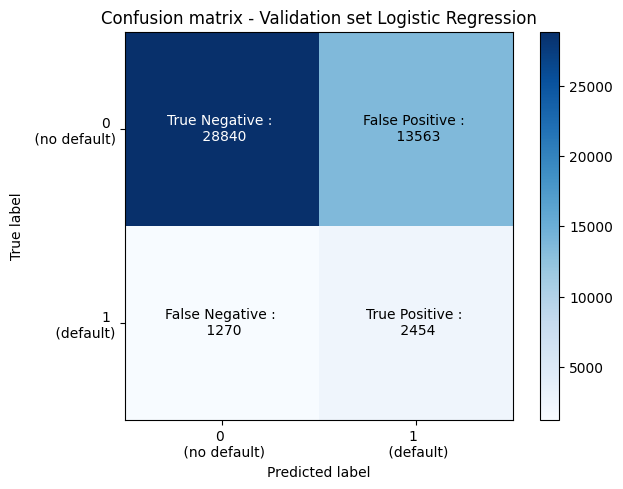

In [43]:
# plot confusion matrix
conf_mat_val_reglog = confusion_matrix(y_val, y_val_pred_reglog)
class_names = ['0 \n (no default)', '1 \n (default)']
plt.figure()
plot_confusion_matrix(conf_mat_val , classes=class_names, title='Confusion matrix - Validation set Logistic Regression')
plt.savefig('Confusion matrix - Validation set Logistic Regression.png')
plt.show()

### 1.2.3 - Register model with best hyperparameters

In [46]:
# retrieve best parameters from modelisation results
reglog_best_params = reglog_search.best_params_

In [47]:
# format best parameters from modelisation results
final_params_reglog = {
    key.replace('model__', ''): value
    for key, value in reglog_best_params.items()
    if isinstance(key, str)
}

final_params_reglog

{'class_weight': 'balanced',
 'fit_intercept': False,
 'penalty': None,
 'random_state': 42,
 'solver': 'newton-cg',
 'tol': 0.001}

In [48]:
# assign best parameters to model
best_reglog_classif= LogisticRegression(**final_params_reglog)
best_reglog_classif

LogisticRegression(class_weight='balanced', fit_intercept=False, penalty=None,
                   random_state=42, solver='newton-cg', tol=0.001)

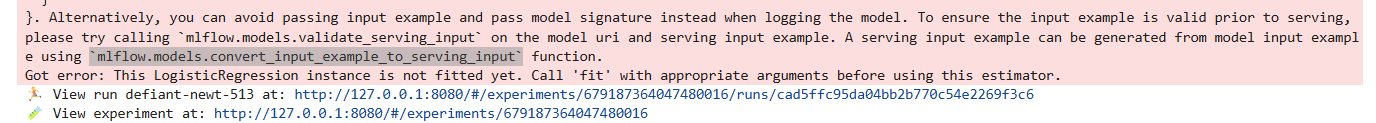

In [84]:
over_reglog_best = SMOTE(sampling_strategy=0.1, k_neighbors=best_k_reglog, random_state=rs)
under_reglog_best = RandomUnderSampler(sampling_strategy=0.5, random_state=rs)

# Define the pipeline with both preprocessing and a model
pipe_reglog_best = Pipeline_imb(steps=[('preprocessor', preproc_lin), ('oversampling', over_reglog_best), ('undersampling', under_reglog_best),
                                       ('model', best_reglog_classif)])

# Fit the pipeline to your data
pipe_reglog_best.fit(X_train, y_train.values.ravel())

# Make predictions on a small subset of data
reglog_example = pipe_reglog_best.predict(X_val.head())

# Convert the predictions to a DataFrame
reglog_example = pd.DataFrame(reglog_example).reset_index(drop=True)

# Create an input example
input_example = pd.DataFrame(X_val.head())

# Manually infer the model signature
signature_reglog = infer_signature(input_example, pipe_reglog_best.predict(input_example))

# Log the model with the manually inferred signature
with mlflow.start_run(run_name="Logistic Regression Model Registration") as run:
    mlflow.sklearn.log_model(pipe_reglog_best, "logistic_regression_model", signature=signature_reglog, input_example=input_example)

2025/03/24 20:47:38 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'a1799475062f4169a8ce771ecc313757', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/03/24 20:47:38 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2025/03/24 20:47:38 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2025/03/24 20:47:38 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2025/03/24 20:47:41 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signatu

🏃 View run nebulous-asp-939 at: http://127.0.0.1:8080/#/experiments/721779257270466137/runs/a1799475062f4169a8ce771ecc313757
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/721779257270466137


2025/03/24 20:47:41 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '277967261a144f8caf4aeda8b9c90002', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


🏃 View run clumsy-rat-393 at: http://127.0.0.1:8080/#/experiments/721779257270466137/runs/277967261a144f8caf4aeda8b9c90002
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/721779257270466137


C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run Logistic Regression Model Registration at: http://127.0.0.1:8080/#/experiments/721779257270466137/runs/2e2f21c3927445c48ae8c45e80126cb4
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/721779257270466137


In [90]:
model_name = "logistic_regression_model"

# Check if the model already exists
try:
    client.get_registered_model(model_name)
except mlflow.exceptions.RestException as e:
    if "RESOURCE_DOES_NOT_EXIST" in str(e):
        # Create a new registered model
        client.create_registered_model(model_name)
    else:
        raise

# Get the latest run ID for the model
runs = client.search_runs(experiment_ids=[client.get_experiment_by_name("Default").experiment_id])
latest_run_id = None
for run in runs:
    if run.data.tags.get('mlflow.runName') == "logistic_regression_model":
        latest_run_id = run.info.run_id
        break

# Create a new model version
client.create_model_version(
    name=model_name,
    source=f"runs:/{latest_run_id}/{model_name}",
    run_id=latest_run_id
)

print(f"Model '{model_name}' registered successfully.")


2025/03/24 20:50:55 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: logistic_regression_model, version 8


Model 'logistic_regression_model' registered successfully.


## 1.3 - LightGBM

### 1.3.1 - Threshold optimisation

**Source: https://machinelearningmastery.com/threshold-moving-for-imbalanced-classification/**

In [91]:
# Predict probabilities with the best model
y_val_pred_proba_lgbm = pipe_lgbm_best.predict_proba(X_val)[:,1]

# Define thresholds to evaluate
thresholds_lgbm = np.arange(0, 1, 0.001)

# Evaluate each threshold using F2 score
scores_lgbm = [fbeta_score(y_val, (y_val_pred_proba_lgbm >= t).astype('int'), beta=2) for t in thresholds_lgbm]

# Find the optimal threshold
optimal_threshold_lgbm_idx = np.argmax(scores_lgbm)
optimal_threshold_lgbm = thresholds_lgbm[optimal_threshold_lgbm_idx]

print(f"Optimal Threshold: {optimal_threshold_lgbm:.3f}, F2 Score: {np.max(scores_lgbm):.5f}")

Optimal Threshold: 0.477, F2 Score: 0.41204


### 1.3.2 - Modelisation

In [53]:
# Provide an experiment description that will appear in the UI
experiment_description_2 = (
    "This is the client scoring project. "
    "This experiment contains the lightGBM model for prediction of a client's risk of default."
)

# Provide searchable tags that define characteristics of the runs that will be in this experiment
experiment_tags_2 = {
    "project_name": "client-scoring",
    "model_name": "lightGBM-classification",
    "mlflow.note.content": experiment_description_2,
}

# Create the experiment, providing a unique name
lightgbm_experiment = client.create_experiment(name="LightGBM-Classification", tags=experiment_tags_2)

In [54]:
# If the above returns "RestException: RESOURCE_ALREADY_EXISTS: Experiment 'LightGBM-Classification' already exists.", run:
mlflow.set_experiment("LightGBM-Classification")

<Experiment: artifact_location='mlflow-artifacts:/721779257270466137', creation_time=1742566187381, experiment_id='721779257270466137', last_update_time=1742738969410, lifecycle_stage='active', name='LightGBM-Classification', tags={'mlflow.note.content': 'This is the client scoring project. This experiment '
                        'contains the lightGBM model for prediction of a '
                        "client's risk of default.",
 'model_name': 'lightGBM-regression',
 'project_name': 'client-scoring'}>

In [55]:
# Enable MLflow's automatic experiment tracking for lightGBM
# Autologging captures the following information: Framework	Metrics	Parameters	Tags	Artifacts LightGBM	user-specified metrics	lightgbm.train parameters
# MLflow Model (LightGBM model) with model signature on training end; feature importance; input example;
# If early stopping is activated, metrics at the best iteration will be logged as an extra step/iteration.
mlflow.lightgbm.autolog()

In [68]:
# avoid error message when running GridSearch with OneHotEncoder in Pipe
# Pandas output does not support sparse data. Set sparse_output=False to output pandas dataframes or disable Pandas output via
# ` ohe.set_output(transform="default")
set_config(transform_output="default")
# set_config(transform_output="pandas")

In [69]:
timestamp_2 = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

# Define the run name
run_name_2 = f'lightgbm_training_{timestamp_2}'

# Start a new MLflow run with a specified name
with mlflow.start_run(run_name=run_name_2) as run:

    k_values = [3, 5, 8, 11, 13]
    
    business_score = make_scorer(business_value, threshold=optimal_threshold_lgbm)

    # for hyperparameters tuning, see https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
    param_grid_lgbm = [{'model__max_depth': [6, 8, 10], # decrease for faster convergence
                     'model__num_leaves':[60, 200, 800], # should be smaller than 2^(max_depth) - decrease for faster convergence
                     'model__min_data_in_leaf':[200, 400], # very important parameter to prevent over-fitting in a leaf-wise tree, hundreds or thousands is enough for a large dataset
                     'model__learning_rate': [0.05, 0.1, 0.2], # increase if decreasing num_iterations                     
                     'model__min_gain_to_split': [0.001], # default is 0 (no gain too small) - increase to reduce training time
                     'model__is_unbalance':[True],
                     'model__random_state': [rs]}]

    best_k_lightgbm = None
    best_score_lightgbm = 0

    for k in k_values :
        model = LGBMClassifier(verbose=-1, n_jobs=-1)  # n_jobs=-1 to allow run it on all cores
        over = SMOTE(sampling_strategy=0.1, k_neighbors=k, random_state=rs)
        under = RandomUnderSampler(sampling_strategy=0.5, random_state=rs)
        pipe = Pipeline_imb(steps=[('preprocessor', preproc_ens), ('oversampling', over), ('undersampling', under), ('model', model)])
        kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=rs)
        lightgbm_search = GridSearchCV(pipe, param_grid, cv=kf, scoring=scorers, refit='business_score', error_score='raise', verbose=False)
        lightgbm_search.fit(X_train, y_train.values)

        # Get the best score for this k
        score_lightgbm = lightgbm_search.best_score_
        
        # Update best k if necessary
        if score_lightgbm > best_score_lightgbm:
            best_score_lightgbm = score_lightgbm
            best_k_lightgbm = k

    print(f"Best k: {best_k_lightgbm}")
    print(f"Best Score: {best_score_lightgbm}")

2025/03/24 15:53:05 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Fitting 10 folds for each of 54 candidates, totalling 540 fits


2025/03/24 16:48:15 WARNING mlflow.sklearn.utils: Failed to autolog artifacts for GridSearchCV. Logging error: unhashable type: 'numpy.ndarray'
2025/03/24 16:48:16 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for

Fitting 10 folds for each of 54 candidates, totalling 540 fits


2025/03/24 17:45:01 WARNING mlflow.sklearn.utils: Failed to autolog artifacts for GridSearchCV. Logging error: unhashable type: 'numpy.ndarray'
2025/03/24 17:45:01 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for

...

Fitting 10 folds for each of 54 candidates, totalling 540 fits


2025/03/24 19:37:09 WARNING mlflow.sklearn.utils: Failed to autolog artifacts for GridSearchCV. Logging error: unhashable type: 'numpy.ndarray'
2025/03/24 19:37:10 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for

Fitting 10 folds for each of 54 candidates, totalling 540 fits


2025/03/24 20:40:12 WARNING mlflow.sklearn.utils: Failed to autolog artifacts for GridSearchCV. Logging error: unhashable type: 'numpy.ndarray'
2025/03/24 20:40:13 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for

Best k: 13
Best Score: 0.40964898982676495
🏃 View run lightgbm_training_2025-03-24_15-53-00 at: http://127.0.0.1:8080/#/experiments/721779257270466137/runs/fe43df24be0944798d82297b0d141bb6
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/721779257270466137


In [21]:
lightgbm_results = pd.DataFrame(lightgbm_search.cv_results_)
timestamp = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
lightgbm_results.to_csv(f'lightgbm_results_{timestamp}.csv', index=False)

In [23]:
y_val_pred_lgbm = lightgbm_search.predict(X_val)

scores_val_lgbm = {'F1_score': f1_score(y_val, y_val_pred_lgbm),
          'F2_score': fbeta_score(y_val, y_val_pred_lgbm, beta=2), 
          'AUC': roc_auc_score(y_val, y_val_pred_lgbm),
          'accuracy': accuracy_score(y_val, y_val_pred_lgbm),
          'balanced_accuracy': balanced_accuracy_score(y_val, y_val_pred_lgbm),
          'precision': precision_score(y_val, y_val_pred_lgbm),
          'avg_precision': average_precision_score(y_val, y_val_pred_lgbm),
          'recall': recall_score(y_val, y_val_pred_lgbm)
          'business_score': business_value(y_val, y_val_pred_lgbm, optimal_threshold_lgbm)
           }

scores_val_lgbm

{'F1_score': 0.2626936316695353
 'F2_score': 0.41022712001075123
 'AUC': np.float64(0.6813506028658116)
 'accuracy': 0.7028204739089904
 'balanced_accuracy': np.float64(0.6813506028658116)
 'precision': 0.1642453591606134
 'avg_precision': np.float64(0.13549615374146676)
 'recall': 0.6557465091299678
 'business_score': 0.6809071989249955}


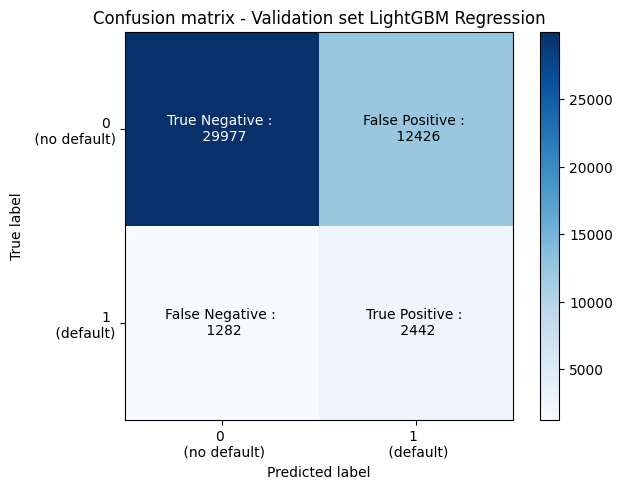

In [74]:
# plot confusion matrix
conf_mat_val_lgbm = confusion_matrix(y_val, y_val_pred_lgbm)
class_names = ['0 \n (no default)', '1 \n (default)']
plt.figure()
plot_confusion_matrix(conf_mat_val_lgbm , classes=class_names, title='Confusion matrix - Validation set LightGBM Regression')
plt.savefig('Confusion matrix - Validation set LightGBM Regression.png')
plt.show()

### 1.3.3 - Register model with best hyperparameters

In [77]:
# retrieve best parameters from modelisation results
lightgbm_best_params = lightgbm_search.best_params_

In [78]:
# format best parameters from modelisation results
final_params_lgbm = {
    key.replace('model__', ''): value
    for key, value in lightgbm_best_params.items()
    if isinstance(key, str)
}

final_params_lgbm

{'is_unbalance': True,
 'learning_rate': 0.1,
 'max_depth': 6,
 'min_data_in_leaf': 400,
 'min_gain_to_split': 0.001,
 'num_leaves': 60,
 'random_state': 42}

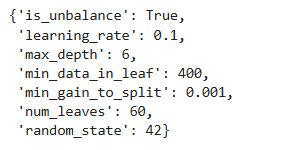

In [79]:
# assign best parameters to model
best_lgbm_classif= LGBMClassifier(**final_params_lgbm)
best_lgbm_classif

LGBMClassifier(is_unbalance=True, max_depth=6, min_data_in_leaf=400,
               min_gain_to_split=0.001, num_leaves=60, random_state=42)

In [80]:
over_lgbm_best = SMOTE(sampling_strategy=0.1, k_neighbors= best_k_lightgbm, random_state=rs)
under_lgbm_best = RandomUnderSampler(sampling_strategy=0.5, random_state=rs)
        
# Define the pipeline with both preprocessing and a model
pipe_lgbm_best = Pipeline_imb(steps=[('preprocessor', preproc_ens), ('oversampling', over_lgbm_best), ('undersampling', under_lgbm_best),
                                     ('model', best_lgbm_classif)])

# Fit the pipeline to your data
pipe_lgbm_best.fit(X_train, y_train.values.ravel())

# Make predictions on a small subset of data
lgbm_example = pipe_lgbm_best.predict(X_val.head())

# Convert the predictions to a DataFrame
lgbm_example = pd.DataFrame(lgbm_example).reset_index(drop=True)

# Create an input example
input_example_lgbm = pd.DataFrame(X_val.head())

# Manually infer the model signature
signature_lgbm = infer_signature(input_example_lgbm, pipe_lgbm_best.predict(input_example_lgbm))

# Log the model with the manually inferred signature
with mlflow.start_run(run_name="LightGBM Classification Model Registration") as run:
    mlflow.sklearn.log_model(pipe_lgbm_best, "lightGBM_classification_model", signature=signature_lgbm, input_example=input_example_lgbm)

2025/03/24 20:42:20 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '588a0a85b52e4de3b67f0fd268da450d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/03/24 20:42:20 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2025/03/24 20:42:20 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2025/03/24 20:42:20 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2025/03/24 20:42:23 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signatu

🏃 View run carefree-donkey-262 at: http://127.0.0.1:8080/#/experiments/721779257270466137/runs/588a0a85b52e4de3b67f0fd268da450d
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/721779257270466137


2025/03/24 20:42:23 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd63b59f88521491a8e35ac28f2f73b57', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current lightgbm workflow


🏃 View run rumbling-koi-101 at: http://127.0.0.1:8080/#/experiments/721779257270466137/runs/d63b59f88521491a8e35ac28f2f73b57
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/721779257270466137


C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run LightGBM Classification Model Registration at: http://127.0.0.1:8080/#/experiments/721779257270466137/runs/bd34d07929614140ad3738a6851944f2
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/721779257270466137


In [81]:
model_name_lgbm = "lightGBM_classification_model"

# Check if the model already exists
try:
    client.get_registered_model(model_name_lgbm)
except mlflow.exceptions.RestException as e:
    if "RESOURCE_DOES_NOT_EXIST" in str(e):
        # Create a new registered model
        client.create_registered_model(model_name_lgbm)
    else:
        raise

# Get the latest run ID for the model
runs = client.search_runs(experiment_ids=[client.get_experiment_by_name("Default").experiment_id])
latest_run_id = None
for run in runs:
    if run.data.tags.get('mlflow.runName') == "lightGBM_classification_model":
        latest_run_id = run.info.run_id
        break

# Create a new model version
client.create_model_version(
    name=model_name_lgbm,
    source=f"runs:/{latest_run_id}/{model_name_lgbm}",
    run_id=latest_run_id
)

print(f"Model '{model_name_lgbm}' registered successfully.")


2025/03/24 20:42:32 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: lightGBM_classification_model, version 1


Model 'lightGBM_classification_model' registered successfully.


## 1.4 - XGBoost

### 1.4.1 - Threshold optimisation

**Source: https://machinelearningmastery.com/threshold-moving-for-imbalanced-classification/**

In [203]:
# Predict probabilities with the best model
y_val_pred_proba_xgb = pipe_xgb_best.predict_proba(X_val)[:,1]

# Define thresholds to evaluate
thresholds_xgb = np.arange(0, 1, 0.001)

# Evaluate each threshold using F2 score
scores_xgb = [fbeta_score(y_val, (y_val_pred_proba_xgb >= t).astype('int'), beta=2) for t in thresholds_xgb]

# Find the optimal threshold
optimal_threshold_xgb_idx = np.argmax(scores_xgb)
optimal_threshold_xgb = thresholds_xgb[optimal_threshold_xgb_idx]

print(f"Optimal Threshold: {optimal_threshold_xgb:.3f}, F2 Score: {np.max(scores_xgb):.5f}")
# print("Optimal Threshold: 0.074, F2 Score: 0.78236")

Optimal Threshold: 0.578, F2 Score: 0.39288


### 1.4.2 - Modelisation

In [185]:
# Provide an experiment description that will appear in the UI
experiment_description_3 = (
    "This is the client scoring project. "
    "This experiment contains the XGBoost model for prediction of a client's risk of default."
)

# Provide searchable tags that define characteristics of the runs that will be in this experiment
experiment_tags_3 = {
    "project_name": "client-scoring",
    "model_name": "XGBoost-classification",
    "mlflow.note.content": experiment_description_3,
}

# Create the experiment, providing a unique name
xgboost_experiment = client.create_experiment(name="XGBoost-Classification", tags=experiment_tags_3)

In [186]:
# If the above returns "RestException: RESOURCE_ALREADY_EXISTS: Experiment 'XGBoost-Classification' already exists.", run:
mlflow.set_experiment("XGBoost-Classification")

<Experiment: artifact_location='mlflow-artifacts:/400590773645889666', creation_time=1742637835711, experiment_id='400590773645889666', last_update_time=1742738978553, lifecycle_stage='active', name='XGBoost-Classification', tags={'mlflow.note.content': 'This is the client scoring project. This experiment '
                        'contains the XGBoost model for prediction of a '
                        "client's risk of default.",
 'model_name': 'XGBoost-regression',
 'project_name': 'client-scoring'}>

In [187]:
# Enable MLflow's automatic experiment tracking for XGBoost
# Autologging captures the following information: Framework	Metrics	Parameters	Tags	Artifacts XGBoost	user-specified metrics	XGBoost.train parameters
# MLflow Model (XGBoost model) with model signature on training end; feature importance; input example;
# If early stopping is activated, metrics at the best iteration will be logged as an extra step/iteration.
mlflow.xgboost.autolog()

In [188]:
# avoid error message when running GridSearch with OneHotEncoder in Pipe
# Pandas output does not support sparse data. Set sparse_output=False to output pandas dataframes or disable Pandas output via
# ` ohe.set_output(transform="default")
set_config(transform_output="default")
# set_config(transform_output="pandas")

In [190]:
timestamp_3 = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

# Define the run name
run_name_3 = f'xgboost_training_{timestamp_3}'

# Start a new MLflow run with a specified name
with mlflow.start_run(run_name=run_name_3) as run:

    k_values = [3, 5, 8, 11, 13]
    
    business_score = make_scorer(business_value, threshold=optimal_threshold_xgb)
    
    # for parameters tuning see https://xgboost.readthedocs.io/en/stable/parameter.html and
    # https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html
    param_grid_xgb = [{'model__booster':['gbtree'], # gblinear also available
                     'model__device':['cpu'], # use cuda for GPU acceleration        
                     'model__learning_rate': [0.05, 0.1, 0.3], # see also eta - default is 0.3
                     'model__min_split_loss': [0.1], # see also gamma - default is 0
                     'model__min_child_weight':[5],
                     'model__max_depth': [6, 8], # default is 6
                     'model__max_delta_step' :[5, 8],
                     'model__scale_pos_weight': [(197880/17377)], # Control the balance of positive and negative weights, useful for unbalanced classes.
                      # A typical value to consider: sum(negative instances) / sum(positive instances)
                     'model__n_estimators':[800],
                     'model__subsample': [0.75], # set >=0.5 for good results with uniform sampling method
                     'model__colsample_bytree' : [0.75], # default is 1 - decrease to control overfitting
                     'model__colsample_bylevel' : [0.75], # default is 1 - decrease to control overfitting
                     'model__colsample_bynode' : [0.75], # default is 1 - decrease to control overfitting
                     'model__sampling_method':['uniform'], # gradient-based sampling works only with tree_method=hist and device=cuda
                     'model__random_state': [rs]}]


    best_k_xgb = None
    best_score_xgb = 0

    for k in k_values :
        model = XGBClassifier(verbosity=0, n_thread=-1)  # n_jobs=-1 to allow run it on all cores
        over = SMOTE(sampling_strategy=0.1, k_neighbors=k, random_state=rs)
        under = RandomUnderSampler(sampling_strategy=0.5, random_state=rs)
        pipe = Pipeline_imb(steps=[('preprocessor', preproc_ens), ('oversampling', over), ('undersampling', under), ('model', model)])
        kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=rs)
        xgb_search = GridSearchCV(pipe, param_grid_xgb, cv=kf, scoring=scorers, refit='business_score', error_score='raise', verbose=False)
        xgb_search.fit(X_train, y_train.values)

        # Get the best score for this k
        score_xgb = xgb_search.best_score_
        
        # Update best k if necessary
        if score_xgb > best_score_xgb:
            best_score_xgb = score_xgb
            best_k_xgb = k

    print(f"Best k: {best_k_xgb}")
    print(f"Best Score: {best_score_xgb}")

2025/03/24 23:48:20 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Fitting 10 folds for each of 12 candidates, totalling 120 fits


2025/03/25 00:08:22 WARNING mlflow.sklearn.utils: Failed to autolog artifacts for GridSearchCV. Logging error: unhashable type: 'numpy.ndarray'
2025/03/25 00:08:23 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for

Fitting 10 folds for each of 12 candidates, totalling 120 fits


2025/03/25 00:28:12 WARNING mlflow.sklearn.utils: Failed to autolog artifacts for GridSearchCV. Logging error: unhashable type: 'numpy.ndarray'
2025/03/25 00:28:13 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for

...

Fitting 10 folds for each of 12 candidates, totalling 120 fits


2025/03/25 01:15:09 WARNING mlflow.sklearn.utils: Failed to autolog artifacts for GridSearchCV. Logging error: unhashable type: 'numpy.ndarray'
2025/03/25 01:15:10 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for

Fitting 10 folds for each of 12 candidates, totalling 120 fits


2025/03/25 01:38:08 WARNING mlflow.sklearn.utils: Failed to autolog artifacts for GridSearchCV. Logging error: unhashable type: 'numpy.ndarray'
2025/03/25 01:38:09 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for

Best k: 3
Best Score: 0.38753689186826096
🏃 View run xgboost_training_2025-03-24_23-48-15 at: http://127.0.0.1:8080/#/experiments/400590773645889666/runs/c87394bdd3124a45a9341c2f322fa34c
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/400590773645889666


In [24]:
xgb_results = pd.DataFrame(xgb_search.cv_results_)
timestamp = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
xgb_results.to_csv(f'xgb_results_{timestamp}.csv', index=False)

In [26]:
y_val_pred_xgb = xgb_search.predict(X_val)

scores_val_xgb = {'F1_score': f1_score(y_val, y_val_pred_xgb),
          'F2_score': fbeta_score(y_val, y_val_pred_xgb, beta=2), 
          'AUC': roc_auc_score(y_val, y_val_pred_xgb),
          'accuracy': accuracy_score(y_val, y_val_pred_xgb),
          'balanced_accuracy': balanced_accuracy_score(y_val, y_val_pred_xgb),
          'precision': precision_score(y_val, y_val_pred_xgb),
          'avg_precision': average_precision_score(y_val, y_val_pred_xgb),
          'recall': recall_score(y_val, y_val_pred_xgb),
          'business_score': business_value(y_val, y_val_pred_xgb, optimal_threshold_xgb)
          }

scores_val_xgb

{'F1_score': 0.2310604412340629
 'F2_score': 0.38869206219072994
 'AUC': np.float64(0.6607070853543209)
 'accuracy': 0.6169055000325189
 'balanced_accuracy': np.float64(0.6607070853543209)
 'precision': 0.13787194267019784
 'avg_precision': np.float64(0.12146999322226001)
 'recall': 0.7129430719656283
 'business_score': 0.6696819232092818}


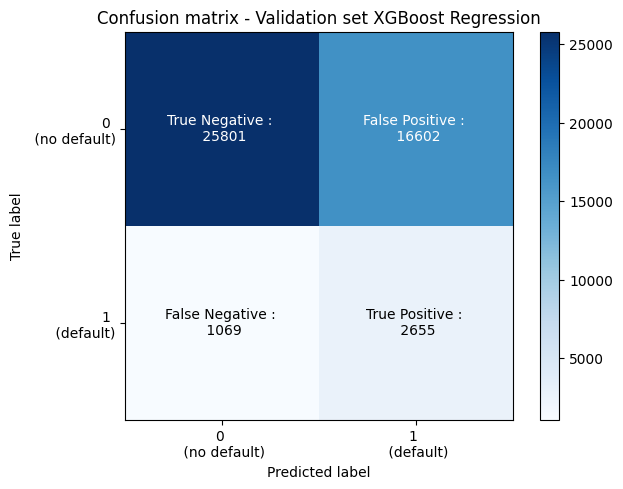

In [195]:
# plot confusion matrix
conf_mat_val_xgb = confusion_matrix(y_val, y_val_pred_xgb)
class_names = ['0 \n (no default)', '1 \n (default)']
plt.figure()
plot_confusion_matrix(conf_mat_val_xgb , classes=class_names, title='Confusion matrix - Validation set XGBoost Regression')
plt.savefig('Confusion matrix - Validation set XGBoost Regression.png')
plt.show()

### 1.4.3 - Register model with best hyperparameters

In [198]:
# retrieve best parameters from modelisation results
xgb_best_params = xgb_search.best_params_

In [199]:
# format best parameters from modelisation results
final_params_xgb = {
    key.replace('model__', ''): value
    for key, value in xgb_best_params.items()
    if isinstance(key, str)
}

final_params_xgb

{'booster': 'gbtree',
 'colsample_bylevel': 0.75,
 'colsample_bynode': 0.75,
 'colsample_bytree': 0.75,
 'device': 'cpu',
 'learning_rate': 0.1,
 'max_delta_step': 5,
 'max_depth': 8,
 'min_child_weight': 5,
 'min_split_loss': 0.1,
 'n_estimators': 800,
 'random_state': 42,
 'sampling_method': 'uniform',
 'scale_pos_weight': 11.38746619094205,
 'subsample': 0.75}

In [200]:
# assign best parameters to model
best_xgb_classif= XGBClassifier(**final_params_xgb)
best_xgb_classif

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=0.75, colsample_bynode=0.75,
              colsample_bytree=0.75, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=5,
              max_depth=8, max_leaves=None, min_child_weight=5,
              min_split_loss=0.1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=None,
              num_parallel_tree=None, ...)

In [201]:
over_xgb_best = SMOTE(sampling_strategy=0.1, k_neighbors=best_k_xgb, random_state=rs)
under_xgb_best = RandomUnderSampler(sampling_strategy=0.5, random_state=rs)
       
# Define the pipeline with both preprocessing and a model
pipe_xgb_best = Pipeline_imb(steps=[('preprocessor', preproc_ens), ('oversampling', over_xgb_best), ('undersampling', under_xgb_best), ('model', best_xgb_classif)])

# Fit the pipeline to your data
pipe_xgb_best.fit(X_train, y_train.values.ravel())

# Make predictions on a small subset of data
xgb_example = pipe_xgb_best.predict(X_val.head())

# Convert the predictions to a DataFrame
xgb_example = pd.DataFrame(xgb_example).reset_index(drop=True)

# Create an input example
input_example_xgb = pd.DataFrame(X_val.head())

# Manually infer the model signature
signature_xgb = infer_signature(input_example_xgb, pipe_xgb_best.predict(input_example_xgb))

# Log the model with the manually inferred signature
with mlflow.start_run(run_name="XGBoost Regression Model Registration") as run:
    mlflow.sklearn.log_model(pipe_xgb_best, "xgboost_classification_model", signature=signature_xgb, input_example=input_example_xgb)

2025/03/25 10:23:58 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd9252a84b5b040369c4a5ea26d65aa49', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/03/25 10:23:58 WARNING mlflow.sklearn: Training metrics will not be recorded because training labels were not specified. To automatically record training metrics, provide training labels as inputs to the model training function.
2025/03/25 10:23:58 WARNING mlflow.sklearn: Failed to infer model signature: the trained model does not have a `predict` or `transform` function, which is required in order to infer the signature
2025/03/25 10:23:58 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!
2025/03/25 10:24:01 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signatu

🏃 View run masked-wren-274 at: http://127.0.0.1:8080/#/experiments/400590773645889666/runs/d9252a84b5b040369c4a5ea26d65aa49
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/400590773645889666


2025/03/25 10:24:02 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ed50b0e2383c4265843479c9fa2615ee', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
2025/03/25 10:24:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:24:06] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."


🏃 View run chill-panda-756 at: http://127.0.0.1:8080/#/experiments/400590773645889666/runs/ed50b0e2383c4265843479c9fa2615ee
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/400590773645889666


C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


🏃 View run XGBoost Regression Model Registration at: http://127.0.0.1:8080/#/experiments/400590773645889666/runs/fd91bb2ad2ec4aa9a3c5290c0dffc52a
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/400590773645889666


In [202]:
model_name_xgb = "xgboost_classification_model"

# Check if the model already exists
try:
    client.get_registered_model(model_name_xgb)
except mlflow.exceptions.RestException as e:
    if "RESOURCE_DOES_NOT_EXIST" in str(e):
        # Create a new registered model
        client.create_registered_model(model_name_xgb)
    else:
        raise

# Get the latest run ID for the model
runs = client.search_runs(experiment_ids=[client.get_experiment_by_name("Default").experiment_id])
latest_run_id = None
for run in runs:
    if run.data.tags.get('mlflow.runName') == "xgboost_classification_model":
        latest_run_id = run.info.run_id
        break

# Create a new model version
client.create_model_version(
    name=model_name_xgb,
    source=f"runs:/{latest_run_id}/{model_name_xgb}",
    run_id=latest_run_id
)

print(f"Model '{model_name_xgb}' registered successfully.")

2025/03/25 10:25:43 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: xgboost_classification_model, version 1


Model 'xgboost_classification_model' registered successfully.


# 2 - Best model choice & evaluation

## 2.1 - Retrain model on entire train + validation dataset

In [20]:
# Provide an experiment description that will appear in the UI
experiment_description_4 = (
    "This is the client scoring project."
    "This experiment contains the final model for prediction of a client's risk of default."
)

# Provide searchable tags that define characteristics of the runs that will be in this experiment
experiment_tags_4 = {
    "project_name": "client-scoring",
    "model_name": "final-model",
    "mlflow.note.content": experiment_description_4,
}

# Create the experiment, providing a unique name
final_experiment = client.create_experiment(name="Final-Scoring-Model", tags=experiment_tags_4)

In [21]:
# If the above returns "RestException: RESOURCE_ALREADY_EXISTS: Experiment 'LightGBM-Regression' already exists.", run:
mlflow.set_experiment("Final-Scoring-Model")

<Experiment: artifact_location='mlflow-artifacts:/699465146797076938', creation_time=1742739070641, experiment_id='699465146797076938', last_update_time=1742739070641, lifecycle_stage='active', name='Final-Scoring-Model', tags={'mlflow.note.content': 'This is the client scoring project.This experiment '
                        "contains the final model for prediction of a client's "
                        'risk of default.',
 'model_name': 'final-model',
 'project_name': 'client-scoring'}>

In [30]:
# Predict probabilities with the best model
# y_val_pred_proba_lgbm = pipe_3.predict_proba(X_train_val)[:,1]

# Define thresholds to evaluate
thresholds_final = np.arange(0, 1, 0.001)

# Evaluate each threshold using F2 score
scores_final = [fbeta_score(y_train_val, (y_score_final >= t).astype('int'), beta=2) for t in thresholds_final]

# Find the optimal threshold
optimal_threshold_final_idx = np.argmax(scores_final)
optimal_threshold_final = thresholds_final[optimal_threshold_final_idx]

print(f"Optimal Threshold: {optimal_threshold_final:.3f}, F2 Score: {np.max(scores_final):.5f}")

Optimal Threshold: 0.502, F2 Score: 0.43765


In [53]:
# Save threshold as a joblib artifact
threshold_path = "optimal_threshold.joblib"
dump(optimal_threshold_final, threshold_path)

['optimal_threshold.joblib']

In [22]:
# params & pipe from best model run
final_params_lgbm = {'is_unbalance': True,
                     'learning_rate': 0.1,
                     'max_depth': 6,
                     'min_data_in_leaf': 400,
                     'min_gain_to_split': 0.001,
                     'num_leaves': 60,
                     'random_state': 42}

best_lgbm_classif= LGBMClassifier(**final_params_lgbm, verbose=-1)

best_k_lightgbm = 13    

In [23]:
# Enable MLflow's automatic experiment tracking for lightGBM
# Autologging captures the following information: Framework	Metrics	Parameters	Tags	Artifacts LightGBM	user-specified metrics	lightgbm.train parameters
# MLflow Model (LightGBM model) with model signature on training end; feature importance; input example;
# If early stopping is activated, metrics at the best iteration will be logged as an extra step/iteration.
mlflow.lightgbm.autolog()

In [24]:
# avoid error message when running GridSearch with OneHotEncoder in Pipe
# Pandas output does not support sparse data. Set sparse_output=False to output pandas dataframes or disable Pandas output via
# ` ohe.set_output(transform="default")
set_config(transform_output="default")
# set_config(transform_output="pandas")

In [25]:
timestamp_4 = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')

# Define the run name
run_name_4 = f'final_model_training_{timestamp_4}'

X_train_val[cat_X] = X_train_val[cat_X].astype('str')

# Start a new MLflow run with a specified name
with mlflow.start_run(run_name=run_name_4) as run:
    model_final = best_lgbm_classif
    final_k = best_k_lightgbm
    over_final = SMOTE(sampling_strategy=0.1, k_neighbors=final_k, random_state=rs)
    under_final = RandomUnderSampler(sampling_strategy=0.5, random_state=rs)
    pipe_final = Pipeline_imb(steps=[('preprocessor', preproc_ens), ('oversampling', over_final), ('undersampling', under_final), ('model', model_final)])
    pipe_final.fit(X_train_val, y_train_val)    

C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


🏃 View run final_model_training_2025-03-27_17-33-45 at: http://127.0.0.1:8080/#/experiments/699465146797076938/runs/ed196b3df74141d1a82ec5457bfee210
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/699465146797076938


In [28]:
y_train_val_pred_final = pipe_final.predict(X_train_val)

final_scores = {'F1_score': f1_score(y_train_val, y_train_val_pred_final),
          'F2_score': fbeta_score(y_train_val, y_train_val_pred_final, beta=2) ,
          'AUC': roc_auc_score(y_train_val, y_train_val_pred_final),
          'accuracy': accuracy_score(y_train_val, y_train_val_pred_final),
          'balanced_accuracy': balanced_accuracy_score(y_train_val, y_train_val_pred_final),
          'precision': precision_score(y_train_val, y_train_val_pred_final),
          'avg_precision': average_precision_score(y_train_val, y_train_val_pred_final),
          'recall': recall_score(y_train_val, y_train_val_pred_final)
          'business_score': business_value(y_train_val, y_train_val_pred_final, optimal_threshold_final)
         }
final_scores

{'F1_score': 0.28017589347617555
 'F2_score': 0.4374414273343061
 'AUC': np.float64(0.705013220451238)
 'accuracy': 0.7100396351727726
 'balanced_accuracy': np.float64(0.7050132204512382)
 'precision': 0.17519895474521915
 'avg_precision': np.float64(0.1467649839816416)
 'recall': 0.6990190038386807
 'business_score': 0.7084629888833621}


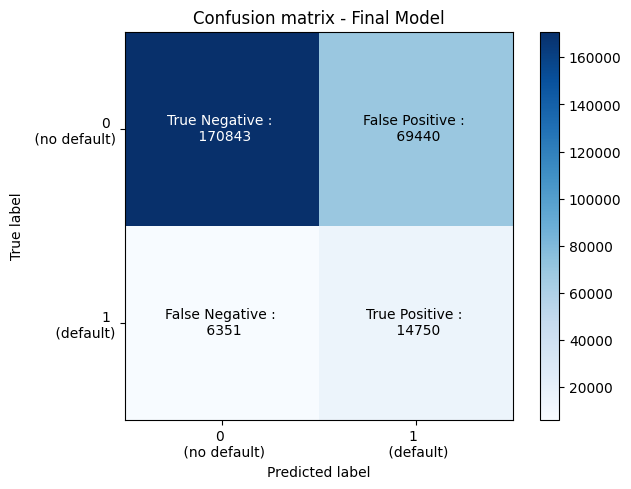

In [27]:
# plot confusion matrix
conf_mat_final = confusion_matrix(y_train_val, y_train_val_pred_final)
class_names = ['0 \n (no default)', '1 \n (default)']
plt.figure()
plot_confusion_matrix(conf_mat_final , classes=class_names, title='Confusion matrix - Final Model')
plt.savefig('Confusion matrix - Final Model.png')
plt.show()

## 2.2 - Register final model

**Once the model is loaded as a pyfunc, the default behavior only supports the predict method. This is evident when you try to call other methods like predict_proba, leading to an AttributeError. This can be limiting, especially when you want to preserve the full capability of the original model.
Source: https://mlflow.org/docs/latest/traditional-ml/creating-custom-pyfunc/notebooks/override-predict/**

In [36]:
class ModelWrapper(PythonModel):
    """
    The ModelWrapper class below is an example of a custom pyfunc that extends MLflow's PythonModel.
    It provides flexibility in the prediction method by using the params argument of the predict method.
    This way, we can specify if we want the regular predict, predict_proba, or predict_log_proba behavior
    when we call the predict method on the loaded pyfunc instance.
    Source: https://mlflow.org/docs/latest/traditional-ml/creating-custom-pyfunc/notebooks/override-predict/
    """

    def __init__(self, model_path):
        self.model_path = model_path
        self.model = None

    def load_context(self, context):
        self.model = load(context.artifacts["model_path"])

    def predict(self, context, model_input, params=None):
        params = params or {"predict_method": "predict"}
        predict_method = params.get("predict_method")

        if predict_method == "predict":
            return self.model.predict(model_input)
        elif predict_method == "predict_proba":
            return self.model.predict_proba(model_input)
        elif predict_method == "predict_log_proba":
            return self.model.predict_log_proba(model_input)
        else:
            raise ValueError(f"The prediction method '{predict_method}' is not supported.")

C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:168: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [65]:
# instanciate model and pipeline
best_lgbm_classif= LGBMClassifier(**final_params_lgbm, verbose=-1)
over_lgbm_best = SMOTE(sampling_strategy=0.1, k_neighbors= best_k_lightgbm, random_state=rs)
under_lgbm_best = RandomUnderSampler(sampling_strategy=0.5, random_state=rs)
pipe_lgbm_best = Pipeline_imb(steps=[('preprocessor', preproc_ens), ('oversampling', over_lgbm_best), ('undersampling', under_lgbm_best),
                                     ('model', best_lgbm_classif)])


# get final model parameters
X_train_val[cat_X] = X_train_val[cat_X].astype('str')

final_params_lgbm = {'is_unbalance': True,
                     'learning_rate': 0.1,
                     'max_depth': 6,
                     'min_data_in_leaf': 400,
                     'min_gain_to_split': 0.001,
                     'num_leaves': 60,
                     'random_state': 42}

best_k_lightgbm = 13

# extract pipeline pre-processing steps
preprocessor = pipe_lgbm_best.named_steps['preprocessor']
oversampler = pipe_lgbm_best.named_steps['oversampling']
undersampler = pipe_lgbm_best.named_steps['undersampling']

# apply power transformer
X_preprocessed = preprocessor.fit_transform(X_train_val)
# extract feature names
feature_names = preprocessor.get_feature_names_out()
# feature_names

# apply SMOTE
X_resamp, y_resamp = oversampler.fit_resample(X_preprocessed, y_train_val)
print(X_resamp.shape)
print(y_resamp.shape)

# apply under-sampling
X_resampled, y_resampled = undersampler.fit_resample(X_resamp, y_resamp)
print(X_resampled.shape)
print(y_resampled.shape)

(264311, 63)
(264311, 1)
(72084, 63)
(72084, 1)


In [68]:
X_resampled = pd.DataFrame(X_resampled, columns=feature_names)
y_resampled = pd.DataFrame(y_resampled)

X_resampled.to_csv('X_resampled.csv', index=False)
y_resampled.to_csv('y_resampled.csv', index=False)

In [37]:
# Save the pipeline as a joblib artifact
model_path = "final_model.joblib"
dump(pipe_final, model_path)

# Create an artifacts dictionary
artifacts = {"model_path": model_path}

# Create an input example
input_example_final = X_test.sample(10)
print(input_example_final.shape)

# Convert categorical columns to string type to avoid "MlflowException: Incompatible input types for column NAME_CONTRACT_TYPE.
# Can not safely convert category to <U0." error. Categorical data types in pandas are not directly compatible with MLflow's string type expectations.
input_example_final[cat_X] = input_example_final[cat_X].astype('str')

signature_final = infer_signature(input_example_final, params={"predict_method": "predict_proba"})

(10, 56)


C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [38]:
input_example_final.head(1)

,NAME_CONTRACT_TYPE,INCOME_TYPE,EMPLOYMENT_SECTOR,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_CREDIT,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_EMAIL,REGION_RATING_CLIENT_W_CITY,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,DISPOSABLE_INCOME,DISPOSABLE_INCOME_per_capita,YEAR_BIRTH,YEARS_EMPLOYED_AS_ADULT_%,PHONE_PROVIDED,PHONE_REACHABLE,ADDRESS_MISMATCH,CREDIT_RATING,NB_APPLICATION_DOCUMENTS_%,REQUESTS_ABOUT_CLIENT_1Y,b_AMT_CREDIT_MAX_OVERDUE_max,b_AMT_CREDIT_SUM_OVERDUE_mean,pcb_CNT_INSTALMENT_FUTURE_max,ccb_AMT_CREDIT_LIMIT_ACTUAL_mean,ccb_CNT_DRAWINGS_TOTAL_mean,ccb_CARD_OVERDRAWN_%_mean,ip_EARLY_PMT_mean,ip_AMT_OVERPAID_%_mean,ip_AMT_UNDERPAID_%_mean,pa_AMT_APPLICATION_mean,pa_RATE_DOWN_PAYMENT_mean,pa_NFLAG_INSURED_ON_APPROVAL_sum,pa_REMAINING_CREDIT_DURATION_Y_mean,pa_CREDIT_SECURITY_sum,TOTAL_APPROVED_CREDITS,TOTAL_PAYMENT_DELAYS_DAYS,TOTAL_ACTIVE_CAR_LOANS,TOTAL_ACTIVE_OTHER_LOANS,TOTAL_ACTIVE_CONSUMER_LOANS,TOTAL_ACTIVE_MICRO_LOANS,TOTAL_ACTIVE_MORTGAGES,TOTAL_ACTIVE_CREDIT_CARDS,DEBT_RENEGOCIATIONS,CLIENT_BAD_CREDIT_HISTORY,CLIENT_FRAUD_FLAG,CLIENT_WITHDRAWN_APPLICATIONS,DOWN_PAYMENT_CURR_%,DEBT_RATE_INC_CURR_%,IS_MALE,WHITE_COLLAR,UPPER_EDUCATION,IS_MARRIED,LIVES_INDEPENDENTLY
8390,Cash loans,fixed_salary,tertiary,1,1,536917.50000,-906,-1161,1,1,6,0,0,512455.50000,256227.75000,27,-0.51516,1,1,1,0.43966,0.05000,2,16994.97866,52.51526,12,450000.00000,2.12903,1.55777,4.33803,0.00000,0.01408,91120.50000,0.00000,0,15.35676,0,7,8.32795,0,1,1,0,0,2,2,0,2,0,-0.15840,-1.26051,1,0,1,1,1


In [39]:
# check signature includes wrapper method
signature_final

inputs: 
  ['NAME_CONTRACT_TYPE': string (required), 'INCOME_TYPE': string (required), 'EMPLOYMENT_SECTOR': string (required), 'FLAG_OWN_CAR': long (required), 'FLAG_OWN_REALTY': long (required), 'AMT_CREDIT': double (required), 'DAYS_REGISTRATION': long (required), 'DAYS_ID_PUBLISH': long (required), 'FLAG_EMAIL': long (required), 'REGION_RATING_CLIENT_W_CITY': long (required), 'OBS_60_CNT_SOCIAL_CIRCLE': long (required), 'DEF_60_CNT_SOCIAL_CIRCLE': long (required), 'DAYS_LAST_PHONE_CHANGE': long (required), 'DISPOSABLE_INCOME': double (required), 'DISPOSABLE_INCOME_per_capita': double (required), 'YEAR_BIRTH': long (required), 'YEARS_EMPLOYED_AS_ADULT_%': double (required), 'PHONE_PROVIDED': long (required), 'PHONE_REACHABLE': long (required), 'ADDRESS_MISMATCH': long (required), 'CREDIT_RATING': double (required), 'NB_APPLICATION_DOCUMENTS_%': double (required), 'REQUESTS_ABOUT_CLIENT_1Y': long (required), 'b_AMT_CREDIT_MAX_OVERDUE_max': double (required), 'b_AMT_CREDIT_SUM_OVERDUE_

In [42]:
# Log the model using mlflow.pyfunc.log_model NOT mlflow.lightgbm.log_model !!
with mlflow.start_run(run_name="Final_Model_Registration") as run:
    model_name = "Final_Scoring_Model"
    mlflow.pyfunc.log_model(python_model=ModelWrapper(model_path=model_path),
                            artifact_path="Final_Scoring_Model",
                            artifacts=artifacts,
                            signature=signature_final,
                            input_example=input_example_final,
                            pip_requirements=["scikit-learn", "pandas", "lightgbm", "joblib", "numpy", "imbalanced-learn"])

    # Get the client to retrieve the model version
    from mlflow.tracking import MlflowClient
    client = MlflowClient()

    # Check if the model exists
    try:
        model = client.get_registered_model(model_name)
        latest_version = client.get_latest_versions(model_name, stages=None)[0].version
        print(f"Model '{model_name}' logged successfully with version {latest_version}.")
    except Exception as e:
        print(f"Failed to retrieve model version: {e}")

2025/03/27 17:45:53 INFO mlflow.pyfunc: Validating input example against model signature


Model 'Final_Scoring_Model' logged successfully with version 2.
🏃 View run Final_Model_Registration at: http://127.0.0.1:8080/#/experiments/699465146797076938/runs/f2fb5dea36ed499ea4b37d30de4991c3
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/699465146797076938


**NB : f2fb5dea36ed499ea4b37d30de4991c3 is the run that logs the model. The source run is 55c3ad49505d42f8b6d08af08975159b as per below - ALWAYS USE SOURCE RUN TO LOAD MODEL**

In [43]:
# Search for registered models
registered_models = client.search_registered_models()

# Get the final registered model details
registered_model = registered_models[0]

# Extract the latest version details
latest_version = registered_model.latest_versions[0]

# Extract the required information
final_model_info = {
    "model_name": registered_model.name,
    "version": latest_version.version,
    "source_run": latest_version.run_id,
    "model_uri": latest_version.source
}

# Print the extracted information
print(f"Final Model Name: {final_model_info['model_name']}")
print(f"Final Model Version: {final_model_info['version']}")
print(f"Final Model Source Run: {final_model_info['source_run']}")
print(f"Final Model URI: {final_model_info['model_uri']}")

# Pickle the results
with open('final_model_info.pkl', 'wb') as f:
    pickle.dump(final_model_info, f)

print("\nModel information has been pickled to 'final_model_info.pkl'")

Final Model Name: final_scoring_model
Final Model Version: 2
Final Model Source Run: 55c3ad49505d42f8b6d08af08975159b
Final Model URI: mlflow-artifacts:/699465146797076938/55c3ad49505d42f8b6d08af08975159b/artifacts/Final_Scoring_Model

Model information has been pickled to 'final_model_info.pkl'


## 2.3 - Model retrieval & batch inference on test set

In [29]:
# Define thresholds to evaluate
thresholds_final = np.arange(0, 1, 0.001)

# Evaluate each threshold using F2 score
scores_final = [fbeta_score(y_test, (test_data_y_pred['test_data_y_pred'] >= t).astype('int'), beta=2) for t in thresholds_final]

# Find the optimal threshold
optimal_threshold_final_idx = np.argmax(scores_final)
optimal_threshold_final = thresholds_final[optimal_threshold_final_idx]

print(f"Optimal Threshold: {optimal_threshold_final:.3f}, F2 Score: {np.max(scores_final):.5f}")

Optimal Threshold: 0.502, F2 Score: 0.41125


In [24]:
# fetch model from registry by alias
model_name = "Final_Scoring_Model"
alias = "champion"
model_uri = 'runs:/55c3ad49505d42f8b6d08af08975159b/Final_Scoring_Model'

try:
    pyfunc_model = mlflow.pyfunc.load_model(f"models:/{model_name}@{alias}")
    print("Model loaded successfully! \n")    

except Exception as e:
    print(f"Error loading or predicting with the model: {e}")

print("Expected columns in input data: \n", pyfunc_model.metadata.get_input_schema())

Model loaded successfully! 

Expected columns in input data: 
 ['NAME_CONTRACT_TYPE': string (required), 'INCOME_TYPE': string (required), 'EMPLOYMENT_SECTOR': string (required), 'FLAG_OWN_CAR': long (required), 'FLAG_OWN_REALTY': long (required), 'AMT_CREDIT': double (required), 'DAYS_REGISTRATION': long (required), 'DAYS_ID_PUBLISH': long (required), 'FLAG_EMAIL': long (required), 'REGION_RATING_CLIENT_W_CITY': long (required), 'OBS_60_CNT_SOCIAL_CIRCLE': long (required), 'DEF_60_CNT_SOCIAL_CIRCLE': long (required), 'DAYS_LAST_PHONE_CHANGE': long (required), 'DISPOSABLE_INCOME': double (required), 'DISPOSABLE_INCOME_per_capita': double (required), 'YEAR_BIRTH': long (required), 'YEARS_EMPLOYED_AS_ADULT_%': double (required), 'PHONE_PROVIDED': long (required), 'PHONE_REACHABLE': long (required), 'ADDRESS_MISMATCH': long (required), 'CREDIT_RATING': double (required), 'NB_APPLICATION_DOCUMENTS_%': double (required), 'REQUESTS_ABOUT_CLIENT_1Y': long (required), 'b_AMT_CREDIT_MAX_OVERDUE

In [3]:
test_data_y_pred = pd.DataFrame(pyfunc_model.predict(X_test)[:,1], columns=['test_data_y_pred'])
test_data_y_pred.loc[test_data_y_pred['test_data_y_pred'] >= 0.502, 'class'] = 1
test_data_y_pred.loc[test_data_y_pred['test_data_y_pred'] < 0.502, 'class'] = 0

In [31]:
y_test_pred_final = test_data_y_pred['class'].astype(int)

final_test_scores = {'F1_score': f1_score(y_test, y_test_pred_final),
          'F2_score': fbeta_score(y_test, y_test_pred_final, beta=2) ,
          'AUC': roc_auc_score(y_test, y_test_pred_final),
          'accuracy': accuracy_score(y_test, y_test_pred_final),
          'balanced_accuracy': balanced_accuracy_score(y_test, y_test_pred_final),
          'precision': precision_score(y_test, y_test_pred_final),
          'avg_precision': average_precision_score(y_test, y_test_pred_final),
          'recall': recall_score(y_test, y_test_pred_final),
          'business_score': business_value(y_test, y_test_pred_final, optimal_threshold_final)
                     
         }
final_test_scores

{'F1_score':  0.26323442296300287
 'F2_score': 0.41088060253522074
 'AUC': np.float64(0.6819139217927678)
 'accuracy': 0.7034058143820322
 'balanced_accuracy': np.float64(0.6819139217927679)
 'precision': 0.16463455708992927
 'avg_precision': np.float64(0.13579642850089663)
 'recall': 0.6562835660580022
 'business_score': 0.692738803401996}


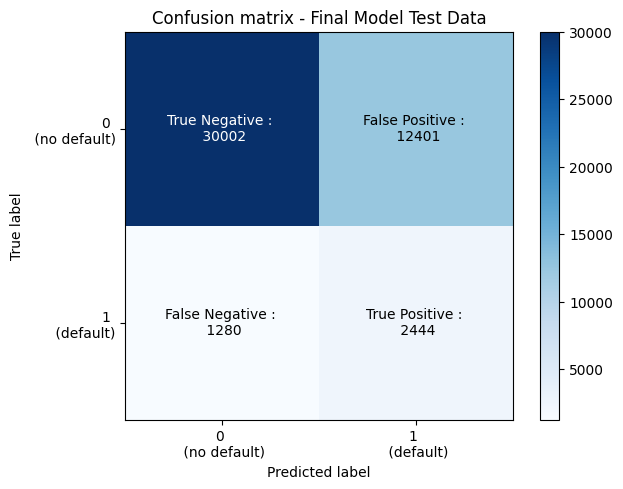

In [33]:
# plot confusion matrix
conf_mat_final = confusion_matrix(y_test, y_test_pred_final)
class_names = ['0 \n (no default)', '1 \n (default)']
plt.figure()
plot_confusion_matrix(conf_mat_final , classes=class_names, title='Confusion matrix - Final Model Test Data')
plt.savefig('Confusion matrix - Final Model Test Data.png')
plt.show()

# 3 - Feature importance

## 3.1 - Create explainer object

### 3.1.1 - For training data

**As our best performing model is LightGBM, we will be using SHAP's TreeExplainer object.**

In [18]:
# avoid error message when running GridSearch with OneHotEncoder in Pipe
# Pandas output does not support sparse data. Set sparse_output=False to output pandas dataframes or disable Pandas output via
# ` ohe.set_output(transform="default")
set_config(transform_output="default")
# set_config(transform_output="pandas")

In [19]:
# get final model parameters
X_train_val[cat_X] = X_train_val[cat_X].astype('str')

final_params_lgbm = {'is_unbalance': True,
                     'learning_rate': 0.1,
                     'max_depth': 6,
                     'min_data_in_leaf': 400,
                     'min_gain_to_split': 0.001,
                     'num_leaves': 60,
                     'random_state': 42}

best_k_lightgbm = 13

In [20]:
# instanciate model and pipeline
best_lgbm_classif= LGBMClassifier(**final_params_lgbm, verbose=-1)
over_lgbm_best = SMOTE(sampling_strategy=0.1, k_neighbors= best_k_lightgbm, random_state=rs)
under_lgbm_best = RandomUnderSampler(sampling_strategy=0.5, random_state=rs)
pipe_lgbm_best = Pipeline_imb(steps=[('preprocessor', preproc_ens), ('oversampling', over_lgbm_best), ('undersampling', under_lgbm_best),
                                     ('model', best_lgbm_classif)])

In [21]:
# create SHAP explainer object - note that SHAP cannot handle pipelines directly (whether sklearn or imblearn) so all steps of the pipleine have to
# be first applied in sequence before generating explainer object on final model

# extract pipeline pre-processing steps
preprocessor = pipe_lgbm_best.named_steps['preprocessor']
oversampler = pipe_lgbm_best.named_steps['oversampling']
undersampler = pipe_lgbm_best.named_steps['undersampling']

# apply power transformer
X_preprocessed = preprocessor.fit_transform(X_train_val)
# extract feature names
feature_names = preprocessor.get_feature_names_out()
# feature_names


# apply SMOTE
X_resamp, y_resamp = oversampler.fit_resample(X_preprocessed, y_train_val)
print(X_resamp.shape)
print(y_resamp.shape)

# apply under-sampling
X_resampled, y_resampled = undersampler.fit_resample(X_resamp, y_resamp)
print(X_resampled.shape)
print(y_resampled.shape)

X_resampled = pd.DataFrame(X_resampled, columns=feature_names)

(264311, 63)
(264311, 1)
(72084, 63)
(72084, 1)


In [22]:
# fit model
best_lgbm_classif.fit(X_resampled, y_resampled)

C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


LGBMClassifier(is_unbalance=True, max_depth=6, min_data_in_leaf=400,
               min_gain_to_split=0.001, num_leaves=60, random_state=42,
               verbose=-1)

In [23]:
# create explainer object and SHAP values
explainer = shap.TreeExplainer(best_lgbm_classif)
shap_values = explainer.shap_values(X_resampled)

C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [24]:
features=X_resampled.columns

### 3.1.2 - For testing data

**- From training set:**

In [25]:
X_test = pd.read_csv('X_test_preprocessed.csv')

In [26]:
# create explainer object and SHAP values
shap_values_test = pd.DataFrame(explainer.shap_values(X_test), columns=X_test.columns)

C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [27]:
# Save to csv
shap_values_test.to_csv('shap_values_test.csv', index=False)

# Save as joblib object
shap_values_test_path = "shap_values_test.joblib"
dump(shap_values_test, shap_values_test_path)

['shap_values_test.joblib']

In [28]:
expected_value = explainer.expected_value

# Save as joblib object
expected_value_path = "expected_value.joblib"
dump(expected_value, expected_value_path)

['expected_value.joblib']

**- From testing dataset:**

In [30]:
# create explainer object and SHAP values
shap_values_test_data = pd.DataFrame(explainer.shap_values(test_data_preprocessed), columns=test_data_preprocessed.columns)

C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [31]:
print(test_data.shape)
print(test_data_preprocessed.shape)
print(shap_values_test_data.shape)

(48744, 56)
(48744, 63)
(48744, 63)


In [32]:
# Save to csv
shap_values_test_data.to_csv('shap_values_test_data.csv', index=False)

## 3.2 - Global feature importance

### 3.2.1 - Bar Plot

In [54]:
plt.figure(figsize=(10, len(feature_names)))
shap_values = explainer.shap_values(X_resampled)
shap.summary_plot(shap_values, X_resampled, plot_type="bar", show=False, feature_names=features, max_display=len(feature_names))
plt.savefig('shap_global_bars_all.png', bbox_inches='tight')
plt.close()

C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


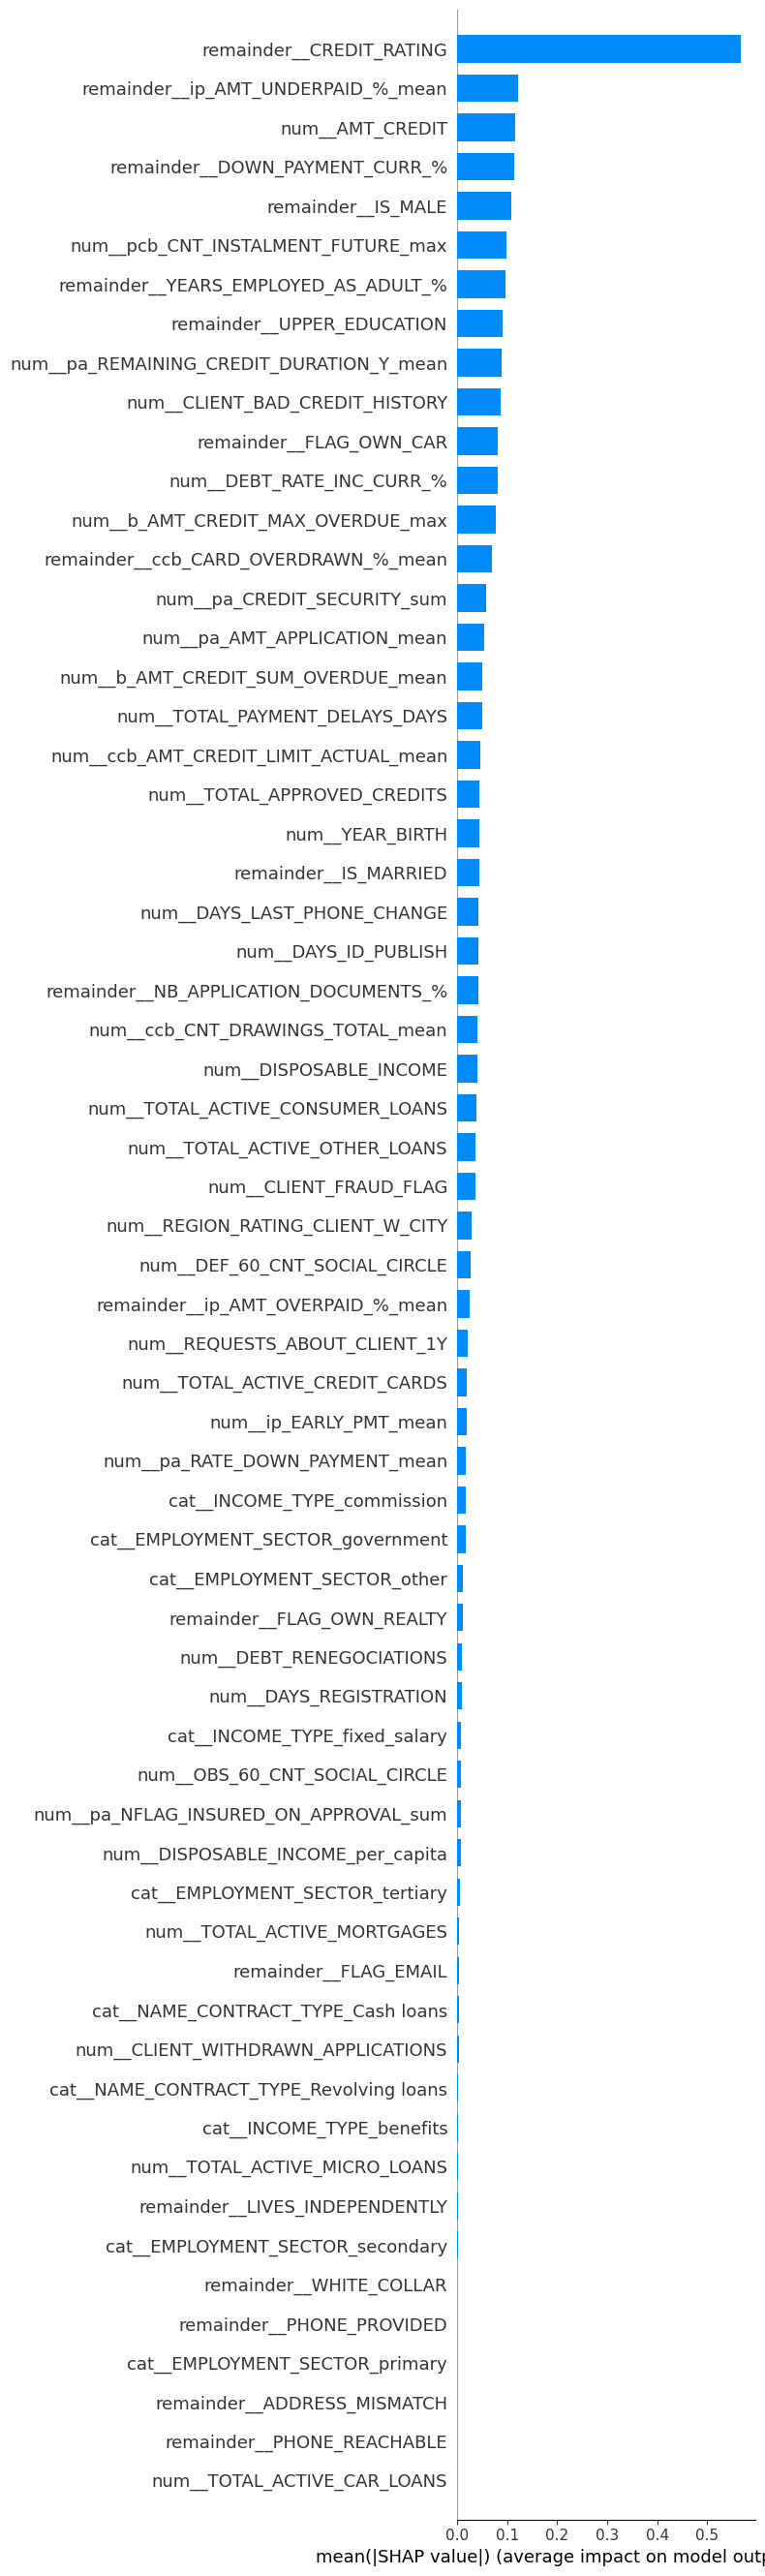

In [55]:
plt.figure(figsize=(10, len(features)))
shap_values = explainer.shap_values(X_resampled)
shap.summary_plot(shap_values, X_resampled, plot_type="bar", show=False, feature_names=features, max_display=20)
plt.savefig('shap_global_bars_first_20.png', bbox_inches='tight')
plt.close()

C:\Users\celin\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


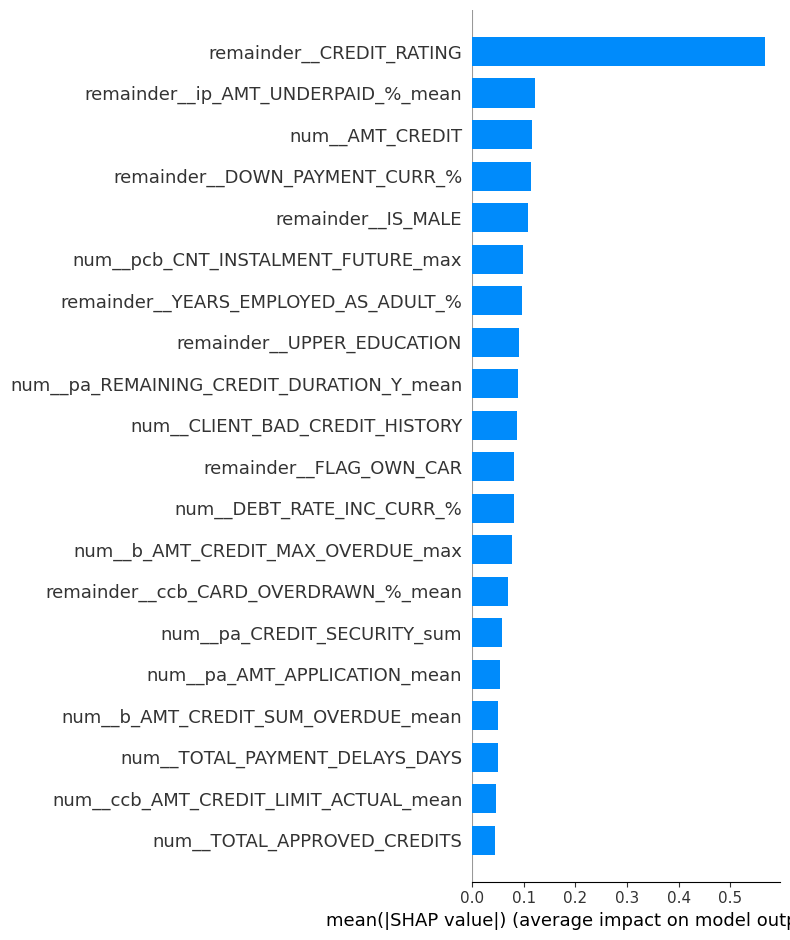

**Interpretation: measures the absolute values of the SHAP values of each feature to determine global importance.**

### 3.2.2 - Decision Plot

In [56]:
shap.decision_plot(explainer.expected_value, shap_values, features=features, show=False, ignore_warnings=True)
plt.savefig('shap_global_decision.png', bbox_inches='tight')
plt.close()

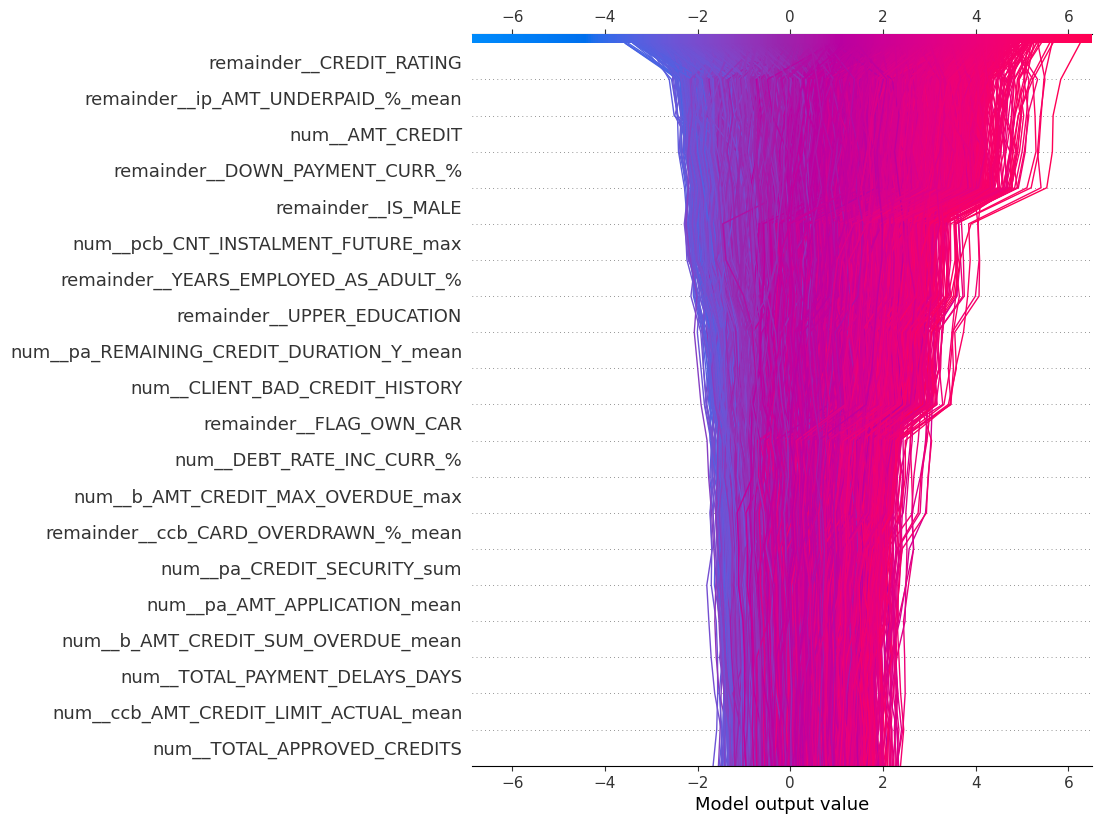

### 3.2.3 - Summary Plot

In [57]:
plt.figure(figsize=(10, len(features)))
shap.summary_plot(shap_values, X_resampled, show=False, feature_names=features, max_display=len(features))
plt.savefig('shap_global_plot_all.png', bbox_inches='tight')
plt.close()

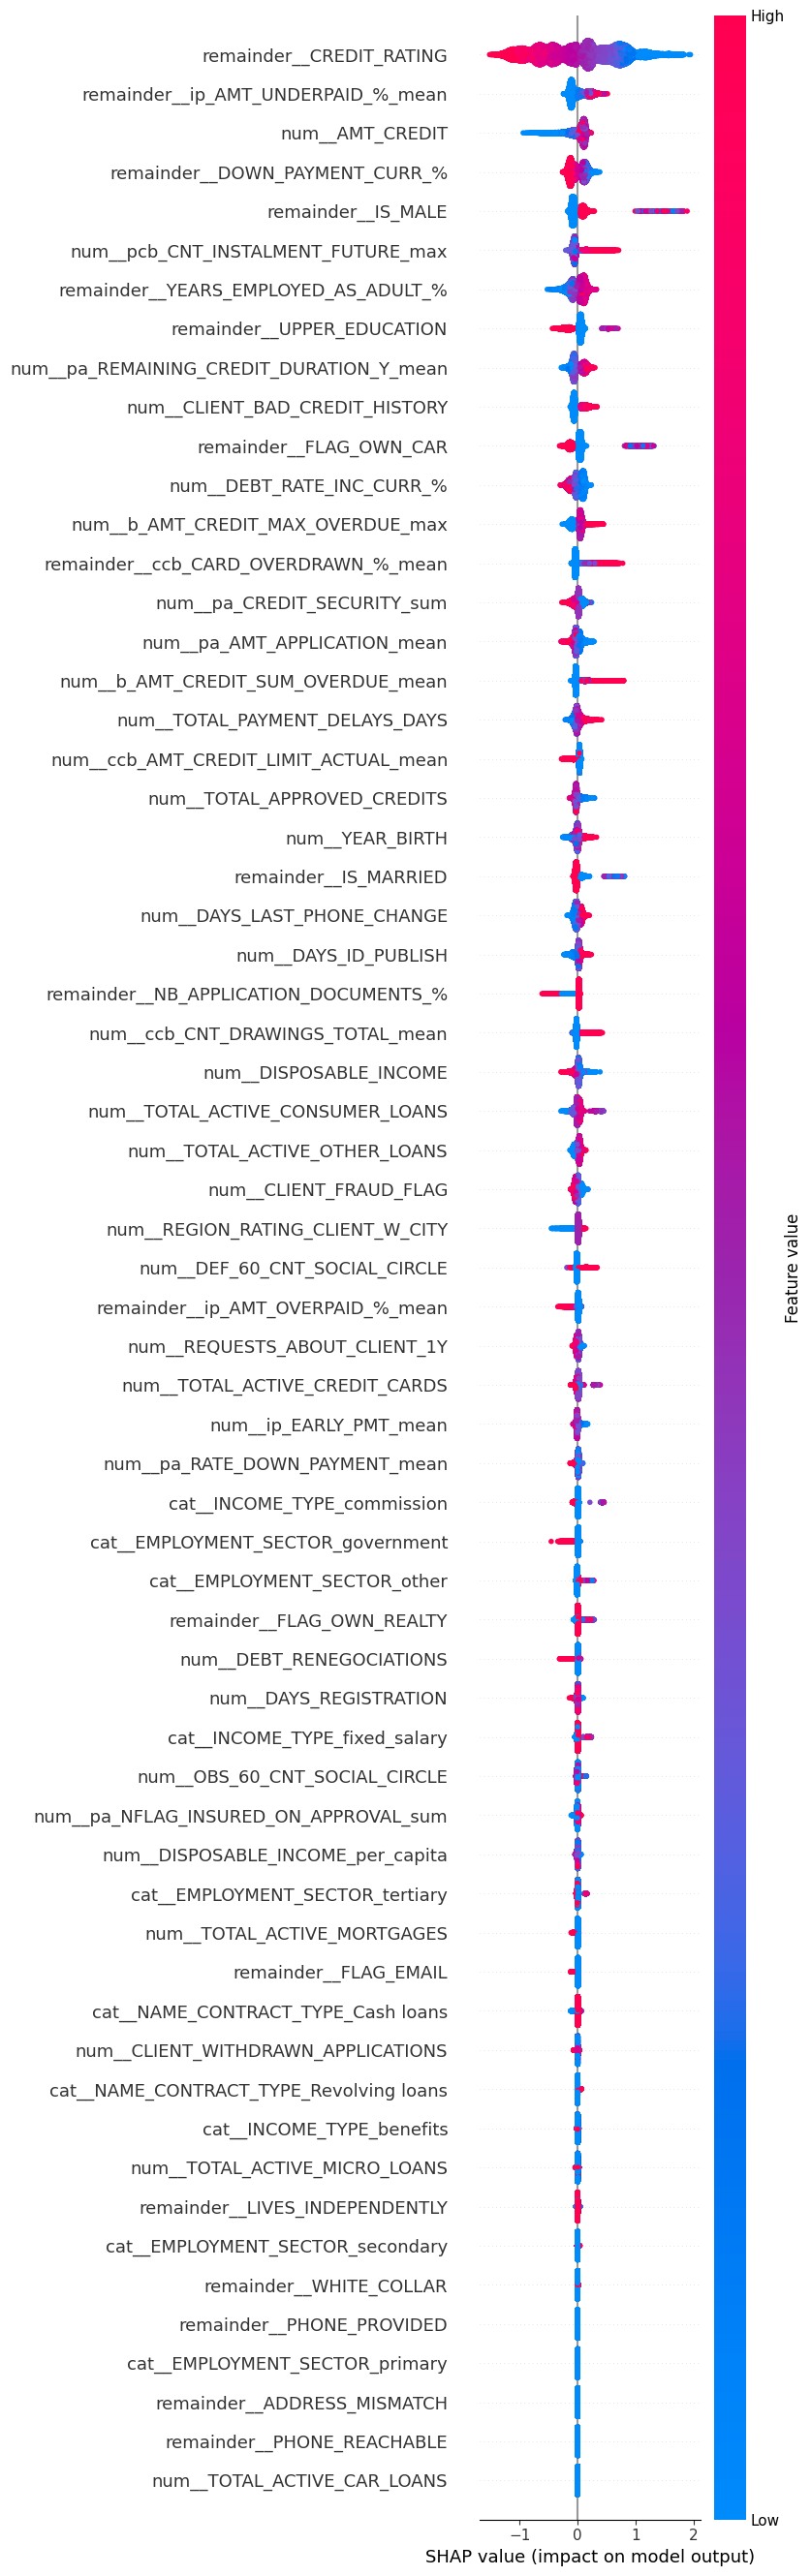

In [58]:
plt.figure(figsize=(10, len(features)))
shap.summary_plot(shap_values, X_resampled, show=False, feature_names=features, max_display=20)
plt.savefig('shap_global_plot_first_20.png', bbox_inches='tight')
plt.close()

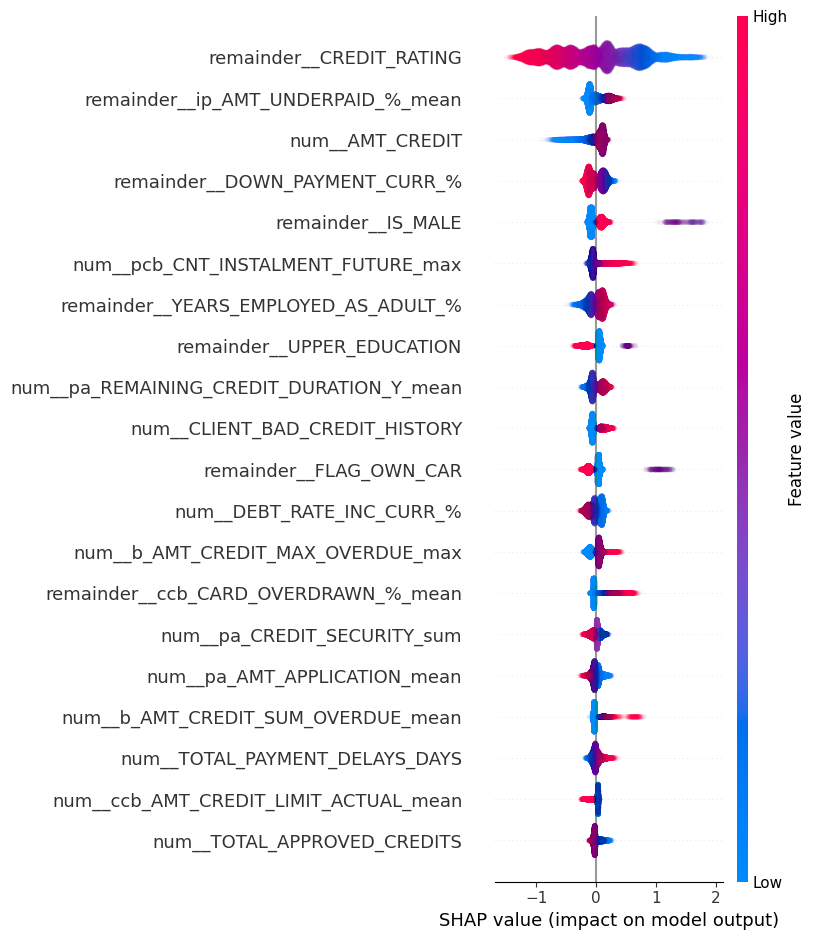

**Interpretation: The color differentiate feature value range scale(smallest or largest), e.g. a higher credit rating value is associated to a smaller SHAP value contribution, i.e. a high credit rating is inversely correlated to a client's risk of default, and so is the fact that a client has some upper education. Conversely, being male is positively correlated to the risk of default.**

### 3.3.3 - Partial Dependence Plot

In [79]:
shap.dependence_plot('remainder__CREDIT_RATING', shap_values, X_resampled, interaction_index=None, show=False)
plt.savefig('dependence_plot_CREDIT_RATING.png', bbox_inches='tight')
plt.close()

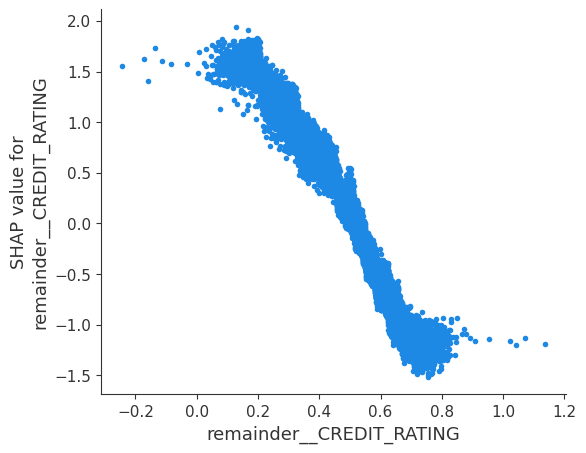

**Interpretation : the Partial Dependency Plot allows to check the relationship between a feature and the target variable. Here, CREDIT_RATING has negative linear relationship with its SHAP value, from which we can infer that CREDIT_RATING has a negative linear relationship with the target variable i.e. the default risk of a client**.

In [80]:
shap.dependence_plot('num__AMT_CREDIT', shap_values, X_resampled, interaction_index=None, show=False)
plt.savefig('dependence_plot_AMT_CREDIT.png', bbox_inches='tight')
plt.close()

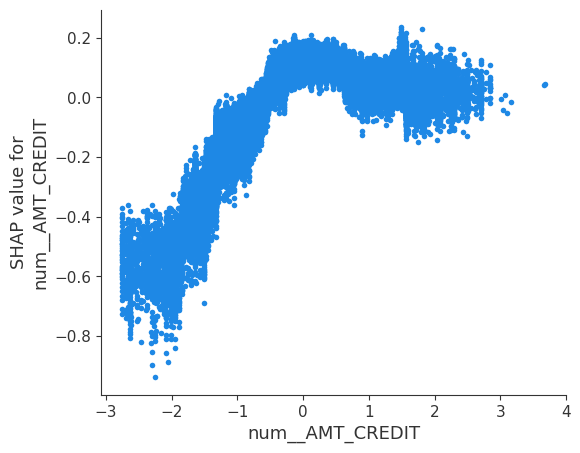

**Interpretation: Similarly, the amount of the credit the client applied for displays a positive correlation with their risk of default.**

### 3.3.4 - Beeswarm plot

In [59]:
plt.figure(figsize=(10, len(features)))
shap.plots.beeswarm(shap.Explanation(values=shap_values, base_values=explainer.expected_value, data=X_resampled, feature_names=features),
                    show=False, max_display=20)
plt.savefig('shap_swarm.png', bbox_inches='tight')
plt.close()

## 3.3 - Local feature importance

In [63]:
# Generate random customer number
cust_list = np.arange(0, X_resampled.shape[0],1)
cli_num = cust_list[random.randrange(len(cust_list))]
print("Customer number =", cli_num)

Customer number = 9173


### 3.3.1 - Force Plot

In [65]:
shap.force_plot(explainer.expected_value, shap_values[cli_num], X_resampled.iloc[cli_num], show=False, matplotlib=True, text_rotation=15,
                feature_names=features)

plt.savefig(f'shap_local_{cli_num}_a.png', bbox_inches='tight')
plt.close()

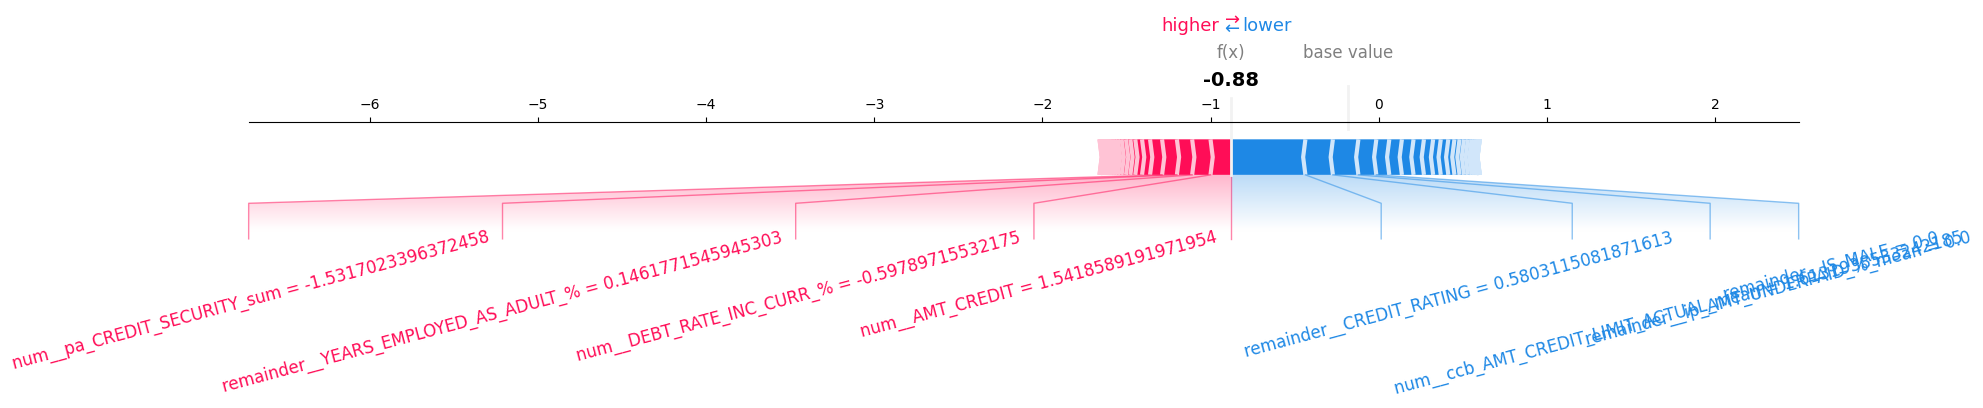

**Interpretation: The base value (not visible due to feature strings length) is average prediction of all instances from dataset X , f(x) is the current instance prediction.  The blue features have negative contribution to prediction, red features have positive contribution (i.e. red features are positively correlated to a client's risk of default), each feature contribution power is reflected by the feature width.**

### 3.3.2 - Waterfall plot

In [66]:
shap_value_i = shap_values[cli_num]
expected_value = explainer.expected_value
shap.plots.waterfall(shap.Explanation(values=shap_value_i, base_values=expected_value, data=X_resampled.iloc[cli_num], feature_names=features), show=False)
plt.savefig(f'shap_local_{cli_num}_b.png', bbox_inches='tight')
plt.close()

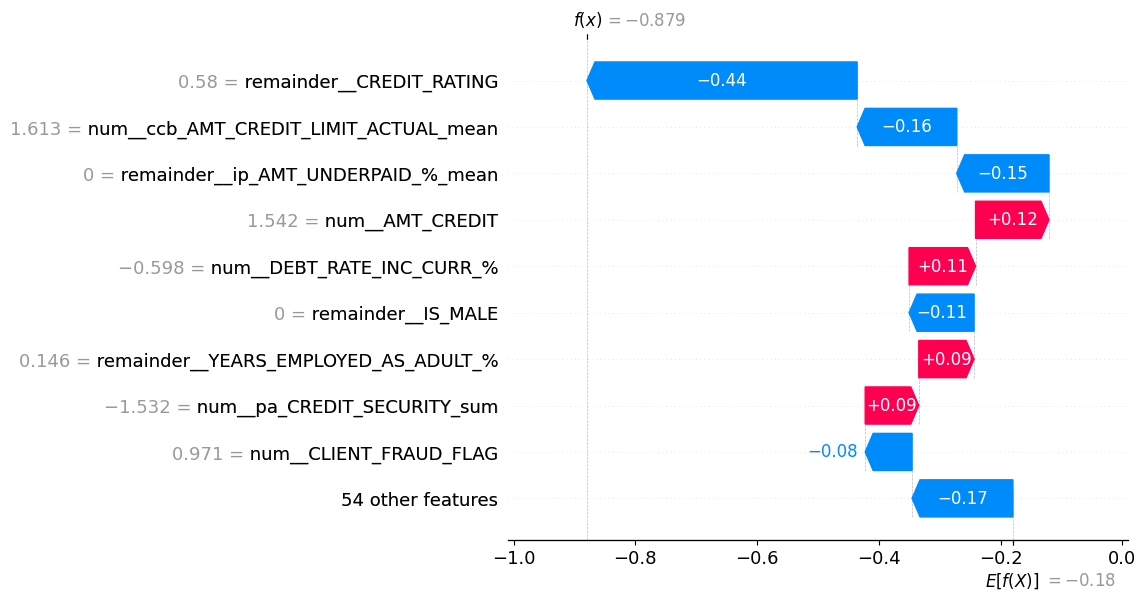